In [1]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib
import matplotlib.colors as mcolors
from matplotlib.colors import Normalize
from matplotlib.colors import LinearSegmentedColormap
import pandas as pd
import seaborn as sns
from scipy.special import softmax
from scipy.stats import gumbel_r
from scipy.stats import norm
from scipy.special import logit

import utilities as utils

In [2]:
### operational parameters ###

savedir = "./Figures/"
savefigflag = True
savedataflag = True # save data produced by this notebook
loaddataflag = True # load data already produced by this notebook, instead of re-running analyses

beads_datadir = "./Data/beads/"
horses_datadir = "./Data/horses/"

# number of threads for parallelized analyses
N_threads = 14


### parameters governing analyses ###

# number of beads to include in X, from current trial backward (bead-prediction experiment) for "fully-optimal" strategy
wsize = 7

# limit for the number of iterations for the IB algorithm
IB_iterlimit = 100000
N_b_ib = 1000 # number of beta points to sample for the standard IB algorithm
max_b_ib = 50 # maximum beta value to sample for the standard IB algorithm
N_b_softmax = 1000 # number of betastar points to sample for the softmax solution
max_b_softmax = 100 # maximum betastar value to sample for the softmax solution


### fixed parameters for the generative structure of the experiments ###

# generative parameters for the bead-prediction experiment
h_=0.99 # jar stay probability
p0_=0.8 # probability of drawing bead type 0 from jar 0
p1_=0.2 # probability of drawing bead type 0 from jar 1
P0 = np.array([[0.5, 0.5]]) # prior over jars for computing posterior probabilities over hidden markov process
H = np.ones((2,2)) - np.abs(np.eye(2)*-1 + h_) # transition matrix
E = np.vstack((np.array([[1,0]])*p0_ + np.array([[0,1]])*(1-p0_),np.array([[1,0]])*p1_ + np.array([[0,1]])*(1-p1_))) # emission matrix

# generative parameters for the horse prediction experiments
paramdict = {
    'lowWS': {
        'weakLLR': 0.45,
        'WSratio': 1.3,
        'p1': 0.06
    },
    'midWS': {
        'weakLLR': 0.2,
        'WSratio': 2.5,
        'p1': 0.08
    },
    'highWS': {
        'weakLLR': 0.18,
        'WSratio': 6.3,
        'p1': 0.02
    }
}

# p(Y) for both tasks
p_Y = np.array([[0.5, 0.5]])


### helper functions ###

def savefig(fig, name, ftype="svg", savefigflag=savefigflag, savedir=savedir):
    if savefigflag:
        fig.savefig(savedir + name + "." + ftype, bbox_inches="tight", dpi=300)

def format_axis(ax):
    ax.tick_params(axis='x', labelsize=5, width=0.5, length=2)
    ax.tick_params(axis='y', labelsize=5, width=0.5, length=2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(0.5)
    ax.spines['left'].set_linewidth(0.5)

In [3]:
def get_beta_matched_bounds(p_XgY,p_Y,N_b=1000,max_b=100,betastar_array=None,iterlimit=100000,N_inits=3,N_threads=1,base_seed=209,enforce_monotonic=False,sort_by_beta=False):
    softmax_curve = utils.get_softmax_IB_curve(p_XgY,p_Y,N_b=N_b,max_b=max_b,betastar_array=betastar_array)
    beta_array = softmax_curve['beta']
    betastar_array = softmax_curve['betastar']
    IB_bound_randinit = utils.get_IB_bound(p_XgY,p_Y,N_b=N_b,max_b=max_b,iterlimit=iterlimit,beta_array=beta_array,init='random',N_inits=N_inits,betastar_array=None,N_threads=N_threads,base_seed=base_seed,enforce_monotonic=enforce_monotonic,sort_by_beta=sort_by_beta)
    IB_bound_softmaxinit = utils.get_IB_bound(p_XgY,p_Y,N_b=N_b,max_b=max_b,iterlimit=iterlimit,beta_array=beta_array,init='softmax',N_inits=N_inits,betastar_array=betastar_array,N_threads=N_threads,base_seed=base_seed,enforce_monotonic=enforce_monotonic,sort_by_beta=sort_by_beta)
    return softmax_curve, IB_bound_randinit, IB_bound_softmaxinit

def get_map_inds(p_YgR,axis=1):
    p_YgR_copy = p_YgR.copy()
    if axis == 1:
        p_YgR_copy = p_YgR_copy.T
    mask = np.zeros_like(p_YgR_copy,dtype=bool)
    map_inds = []
    for ii, p_Ygr in enumerate(p_YgR_copy):
        p_Ygr_copy = p_Ygr.copy()
        p_Ygr_copy[map_inds] = -np.inf
        map_inds.append(np.argmax(p_Ygr_copy))
        mask[ii,np.argmax(p_Ygr_copy)] = True
    if axis == 1:
        mask = mask.T
    inv_map_inds = np.zeros_like(map_inds)
    for ii, ind in enumerate(map_inds):
        inv_map_inds[ind] = ii
    return map_inds, inv_map_inds, mask

def IB_bound_comparison_plot(softmax_curve, IB_bound):
    fig, axs = plt.subplots(1,1,figsize=(3,2),dpi=300)
    axs.plot(softmax_curve['I_XR'],softmax_curve['I_RY'],linewidth=0.7,label='softmax')
    axs.plot(IB_bound['I_XR'],IB_bound['I_RY'],'--k',linewidth=0.7,label='IB')
    axs.set_xlabel('I(X;R)',fontsize=6)
    axs.set_xlim([-0.02, np.log2(IB_bound['p_R'].shape[2])+0.02])
    axs.set_ylabel('I(R;Y)',fontsize=6)
    axs.legend(frameon=False, fontsize=5)
    format_axis(axs)
    plt.tight_layout()

    return fig, axs

def softmax_soln_condition_check(IB_bound):
    N_y = IB_bound['p_R'].shape[2]
    p_Y = np.ones((1,N_y))/N_y
    Hr_max = np.log2(N_y)

    IB_bound['p_R_mapped'] = np.zeros((len(IB_bound['beta']),1,N_y))
    IB_bound['p_RgY'] = np.zeros_like(IB_bound['p_YgR'])
    IB_bound['p_ReYgY_mapped'] = np.zeros((len(IB_bound['beta']),N_y))
    IB_bound['p_RneYgY_mapped'] = np.zeros((len(IB_bound['beta']),(N_y**2-N_y)))
    for ib in range(IB_bound['beta'].shape[0]):
        map_inds, inv_map_inds, mask = get_map_inds(IB_bound['p_YgR'][ib])
        IB_bound['p_RgY'][ib] = IB_bound['p_YgR'][ib] * IB_bound['p_R'][ib] / p_Y
        IB_bound['p_ReYgY_mapped'][ib] = IB_bound['p_RgY'][ib][mask].flatten()
        IB_bound['p_RneYgY_mapped'][ib] = IB_bound['p_RgY'][ib][~mask].flatten()
    
    p_ReYgY_maxdiff = np.max(IB_bound['p_ReYgY_mapped'],axis=1) - np.min(IB_bound['p_ReYgY_mapped'],axis=1)
    p_RneYgY_maxdiff = np.max(IB_bound['p_RneYgY_mapped'],axis=1) - np.min(IB_bound['p_RneYgY_mapped'],axis=1)

    fig, axs = plt.subplots(1,1,figsize=(3,1.8),dpi=300)

    axs.plot(IB_bound['I_XR'],p_ReYgY_maxdiff,linewidth=0.7,label=r'max $p(r=y|y)$ difference')
    axs.plot(IB_bound['I_XR'],p_RneYgY_maxdiff,linewidth=0.7,label=r'max $p(r\neq y|y)$ difference')
    axs.plot([0,Hr_max],[0,0],'--k',linewidth=0.7)
    axs.set_xlabel('I(X;R)',fontsize=6)
    axs.set_ylabel('Max difference',fontsize=6)
    axs.legend(frameon=False, fontsize=5)
    axs.yaxis.get_offset_text().set_fontsize(5)
    format_axis(axs)
    plt.tight_layout()

    return fig, axs

def init_comparison_plot(IB_bound_softmaxinit,IB_bound_randinit):
    IB_bound_softmaxinit['IB_obj_fn'] = IB_bound_softmaxinit['I_XR'] - IB_bound_softmaxinit['beta']*IB_bound_softmaxinit['I_RY']
    IB_bound_randinit['IB_obj_fn'] = IB_bound_randinit['I_XR'] - IB_bound_randinit['beta']*IB_bound_randinit['I_RY']

    fig, axs = plt.subplots(1,1,figsize=(3,1.8),dpi=300)
    # IB_obj_fn_diff = IB_bound_softmaxinit['IB_obj_fn']-softmax_curve['IB_obj_fn']
    # ylim = [np.min(IB_obj_fn_diff)*1.1, np.max(IB_obj_fn_diff)*1.1]

    axs.plot(IB_bound_randinit['beta'],IB_bound_softmaxinit['IB_obj_fn']-IB_bound_randinit['IB_obj_fn'],label='softmax init minus random init',linewidth=0.7)
    xlim = axs.get_xlim()
    axs.plot([xlim[0],xlim[1]],[0,0],'--k',linewidth=0.7)
    axs.set_xlim(xlim)
    axs.set_xlabel(r'$\beta$ value',fontsize=6)
    axs.set_ylabel(r'$\Delta$ IB cost function',fontsize=6)
    axs.yaxis.get_offset_text().set_fontsize(5)
    format_axis(axs)
    axs.set_title('IB cost function difference',fontsize=6)
    # axs.set_ylim(ylim)
    axs.legend(frameon=False, fontsize=5)

    return fig, axs


# def init_comparison_plots(softmax_curve, IB_bound_softmaxinit, IB_bound_randinit):
#     softmax_curve['IB_obj_fn'] = softmax_curve['I_XR'] - softmax_curve['beta']*softmax_curve['I_RY']
#     IB_bound_softmaxinit['IB_obj_fn'] = IB_bound_softmaxinit['I_XR'] - IB_bound_softmaxinit['beta']*IB_bound_softmaxinit['I_RY']
#     IB_bound_randinit['IB_obj_fn'] = IB_bound_randinit['I_XR'] - IB_bound_randinit['beta']*IB_bound_randinit['I_RY']

#     fig, axs = plt.subplots(2,1,figsize=(3,3.5),dpi=300)
#     IB_obj_fn_diff = IB_bound_softmaxinit['IB_obj_fn']-softmax_curve['IB_obj_fn']
#     ylim = [np.min(IB_obj_fn_diff)*1.1, np.max(IB_obj_fn_diff)*1.1]

#     axs[0].plot(IB_bound_randinit['beta'],IB_bound_randinit['IB_obj_fn']-softmax_curve['IB_obj_fn'],label='softmax',linewidth=0.7)
#     axs[0].plot(IB_bound_randinit['beta'],IB_bound_randinit['IB_obj_fn']-IB_bound_softmaxinit['IB_obj_fn'],label='IB softmax init',linewidth=0.7)
#     xlim = axs[0].get_xlim()
#     axs[0].plot([xlim[0],xlim[1]],[0,0],'--k',linewidth=0.7)
#     axs[0].set_xlim(xlim)
#     axs[0].set_xlabel(r'$\beta$ value',fontsize=6)
#     axs[0].set_ylabel(r'$\Delta$ IB cost function (vs random init)',fontsize=6)
#     axs[0].yaxis.get_offset_text().set_fontsize(5)
#     format_axis(axs[0])
#     axs[0].set_title('IB cost function deviation',fontsize=6)
#     axs[0].set_ylim(ylim)
#     axs[0].legend(frameon=False, fontsize=5)

#     Iry_interp_softmax = np.interp(IB_bound_randinit['I_XR'], softmax_curve['I_XR'], softmax_curve['I_RY'])
#     Iry_interp_softmax_init = np.interp(IB_bound_randinit['I_XR'], IB_bound_softmaxinit['I_XR'], IB_bound_softmaxinit['I_RY'])

#     axs[1].plot(IB_bound_randinit['I_XR'],Iry_interp_softmax - IB_bound_randinit['I_RY'],label='softmax',linewidth=0.7)
#     axs[1].plot(IB_bound_randinit['I_XR'],Iry_interp_softmax_init - IB_bound_randinit['I_RY'],label='IB softmax init',linewidth=0.7)
#     xlim = axs[1].get_xlim()
#     axs[1].plot([xlim[0],xlim[1]],[0,0],'--k',linewidth=0.7)
#     axs[1].set_xlim(xlim)
#     axs[1].set_xlabel('I(X;R) (IB bound random init)',fontsize=6)
#     axs[1].set_ylabel(r'$\Delta I(R;Y)$ (vs random init)',fontsize=6)
#     axs[1].yaxis.get_offset_text().set_fontsize(5)
#     format_axis(axs[1])
#     axs[1].set_title(r'$I(R;Y)$ deviation (interpolated values)',fontsize=6)
#     axs[1].legend(frameon=False, fontsize=5)

#     plt.tight_layout()

def compare_softmax_to_IB(softmax_curve,IB_bound):

    N_y = IB_bound['p_R'].shape[2]
    p_R = np.array([[1/N_y]*N_y])
    Hr_max = np.log2(N_y)
    xlim = [-0.02, Hr_max+0.02]

    # softmax_curve['p_YeRgR'] = np.zeros((len(softmax_curve['beta']),N_y))
    # softmax_curve['p_YneRgR'] = np.zeros((len(softmax_curve['beta']),(N_y**2-N_y)))
    # IB_bound['p_R_mapped'] = np.zeros((len(IB_bound['beta']),1,N_y))
    # IB_bound['p_YeRgR_mapped'] = np.zeros((len(IB_bound['beta']),N_y))
    # IB_bound['p_YneRgR_mapped'] = np.zeros((len(IB_bound['beta']),(N_y**2-N_y)))
    IB_bound['p_RgX_maxdiff'] = np.zeros(len(IB_bound['beta']))
    IB_bound['p_RgX_mapped'] = np.zeros_like(IB_bound['p_RgX'])
    # IB_bound['p_RgY'] = np.zeros_like(IB_bound['p_YgR'])
    # IB_bound['p_ReYgY_mapped'] = np.zeros_like(IB_bound['p_YeRgR_mapped'])
    # IB_bound['p_RneYgY_mapped'] = np.zeros_like(IB_bound['p_YneRgR_mapped'])
    for ib in range(IB_bound['beta'].shape[0]):
        map_inds, inv_map_inds, mask = get_map_inds(IB_bound['p_YgR'][ib])
        IB_bound['p_RgX_mapped'][ib] = IB_bound['p_RgX'][ib][:,inv_map_inds]
    #     IB_bound['p_RgY'][ib] = IB_bound['p_YgR'][ib] * IB_bound['p_R'][ib] / p_Y
    #     IB_bound['p_R_mapped'][ib,0] = IB_bound['p_R'][ib,0][inv_map_inds]
    #     IB_bound['p_YeRgR_mapped'][ib] = IB_bound['p_YgR'][ib][mask].flatten()
    #     IB_bound['p_YneRgR_mapped'][ib] = IB_bound['p_YgR'][ib][~mask].flatten()
    #     IB_bound['p_ReYgY_mapped'][ib] = IB_bound['p_RgY'][ib][mask].flatten()
    #     IB_bound['p_RneYgY_mapped'][ib] = IB_bound['p_RgY'][ib][~mask].flatten()
        IB_bound['p_RgX_maxdiff'][ib] = np.max(np.abs(softmax_curve['p_RgX'][ib] - IB_bound['p_RgX_mapped'][ib]))
    #     softmax_curve['p_YeRgR'][ib] = softmax_curve['p_YgR'][ib][np.eye(N_y, dtype=bool)].flatten()
    #     softmax_curve['p_YneRgR'][ib] = softmax_curve['p_YgR'][ib][~np.eye(N_y, dtype=bool)].flatten()

    fig, axs = plt.subplots(3,1,figsize=(3,4.5),dpi=300,sharex=True)

    axs[0].plot(IB_bound['I_XR'],softmax_curve['I_XR']-IB_bound['I_XR'],linewidth=0.7)
    axs[0].plot([0,Hr_max],[0,0],'--k',label='I(X;R) diff = 0',linewidth=0.7)
    axs[0].set_xlim(xlim)
    axs[0].set_ylabel(r'$\Delta I(X;R)$ (softmax-IB bound)',fontsize=6)
    axs[0].yaxis.get_offset_text().set_fontsize(5)
    format_axis(axs[0])
    axs[0].set_title(r'$I(X;R)$ difference',fontsize=6)

    axs[1].plot(IB_bound['I_XR'],softmax_curve['I_RY']-IB_bound['I_RY'],linewidth=0.7)
    axs[1].plot([0,Hr_max],[0,0],'--k',linewidth=0.7)
    axs[1].set_xlim(xlim)
    axs[1].set_ylabel(r'$\Delta I(R;Y)$ (softmax-IB bound)',fontsize=6)
    axs[1].yaxis.get_offset_text().set_fontsize(5)
    format_axis(axs[1])
    axs[1].set_title(r'$I(R;Y)$ difference',fontsize=6)

    axs[2].plot(IB_bound['I_XR'],IB_bound['p_RgX_maxdiff'],linewidth=0.7)
    axs[2].plot([0,Hr_max],[0,0],'--k',linewidth=0.7)
    axs[2].set_xlim(xlim)
    axs[2].set_ylabel(r'max $\Delta p(r|x)$ (softmax-IB bound)',fontsize=6)
    axs[2].yaxis.get_offset_text().set_fontsize(5)
    format_axis(axs[2])
    axs[2].set_title(r'max $p(r|x)$ difference',fontsize=6)

    plt.tight_layout()

    return fig, axs

## Figure B14
Softmax solution compared to IB bound for fully-optimal (7-back) strategy, bead-prediction task

In [4]:
X = utils.get_beads_Xset(wsize)
p_XgY = utils.P_beads_g_jar(X,E,H)
softmax_curve, IB_bound_randinit, IB_bound_softmaxinit = get_beta_matched_bounds(p_XgY,p_Y,N_b=N_b_ib,max_b=max_b_ib,iterlimit=IB_iterlimit,N_threads=N_threads,base_seed=209,enforce_monotonic=False)

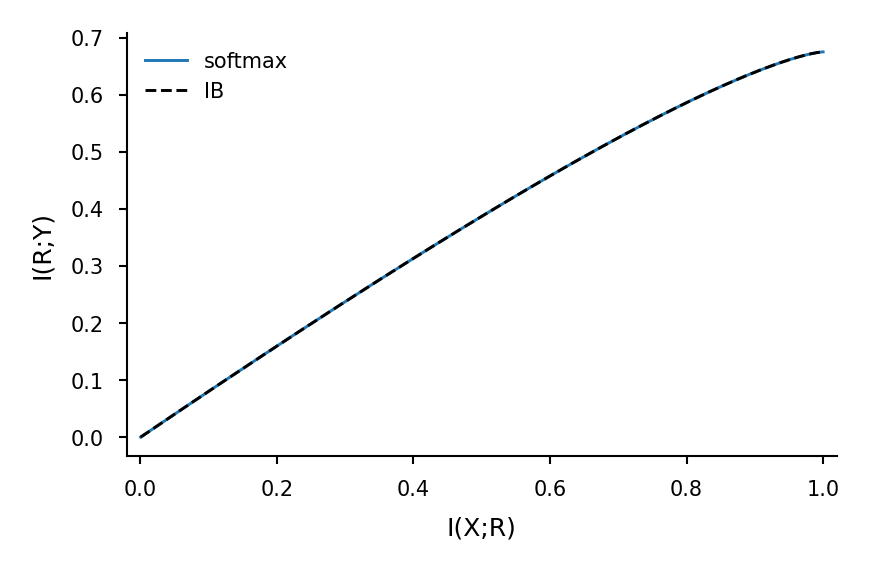

In [5]:
fig, axs = IB_bound_comparison_plot(softmax_curve, IB_bound_softmaxinit)
savefig(fig, 'FigureB14/beads_fully-opt_IB-bound_comparison')

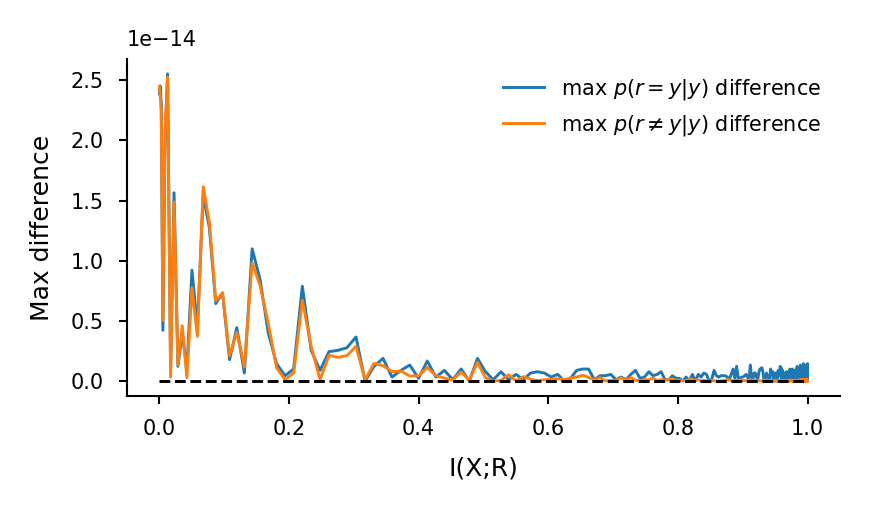

In [6]:
fig, axs = softmax_soln_condition_check(IB_bound_softmaxinit)
savefig(fig, 'FigureB14/beads_fully-opt_softmax_soln_condition_check')

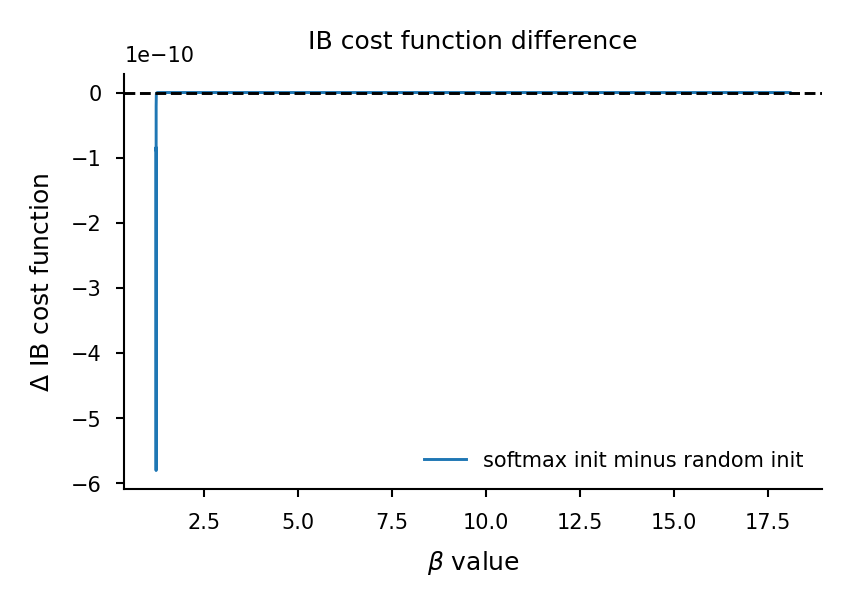

In [7]:
fig, axs = init_comparison_plot(IB_bound_softmaxinit,IB_bound_randinit)
savefig(fig, 'FigureB14/beads_fully-opt_IB-init_comparison')

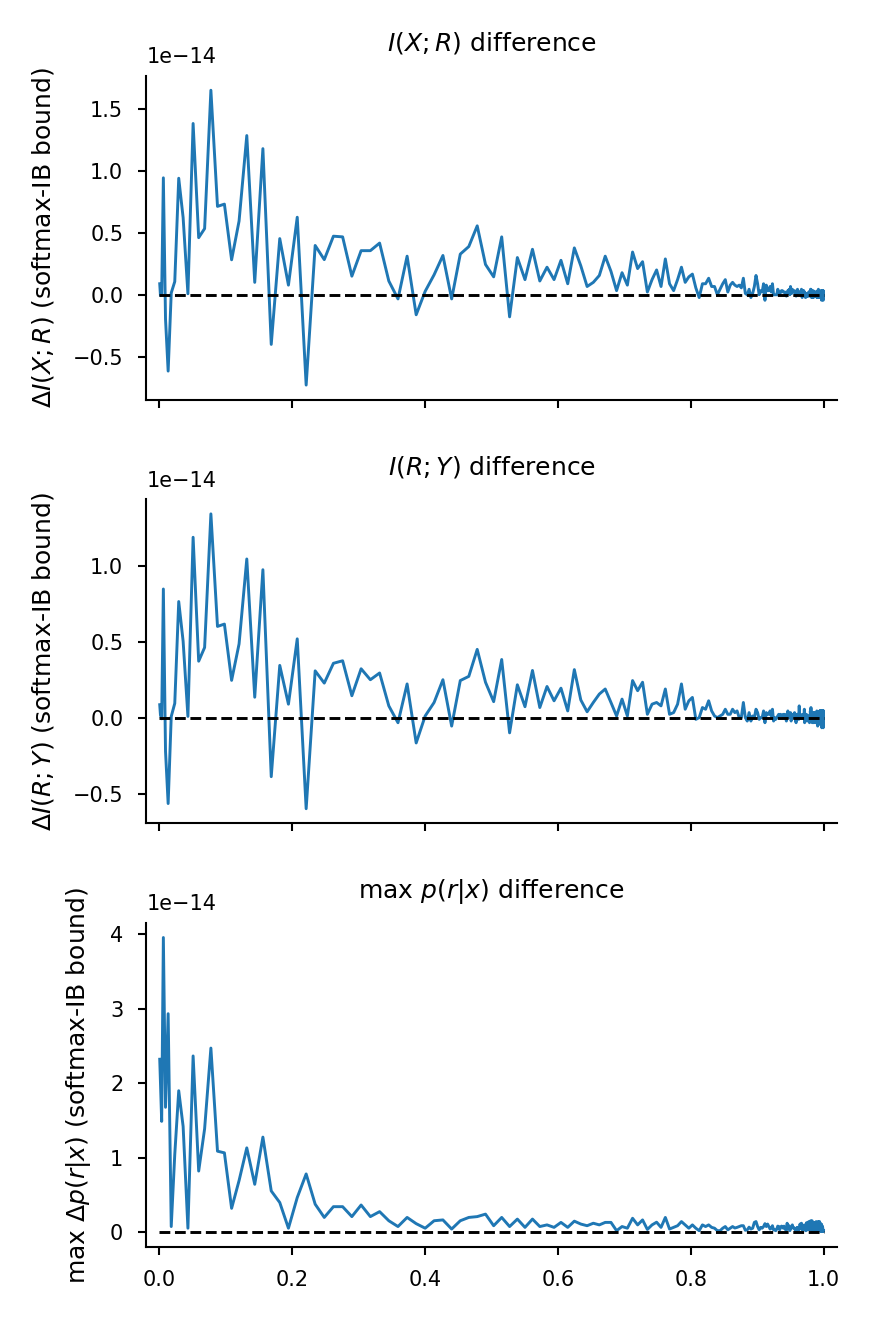

In [8]:
fig, axs = compare_softmax_to_IB(softmax_curve,IB_bound_softmaxinit)
savefig(fig, 'FigureB14/beads_fully-opt_compare_softmax_soln_to_IB')

## Figure B15
Softmax solution compared to IB bound for heuristic (1-back) strategy, bead-prediction task

In [9]:
X = utils.get_beads_Xset(1)
p_XgY = utils.P_beads_g_jar(X,E,H)
softmax_curve, IB_bound_randinit, IB_bound_softmaxinit = get_beta_matched_bounds(p_XgY,p_Y,N_b=N_b_ib,max_b=max_b_ib,iterlimit=IB_iterlimit,N_threads=N_threads,base_seed=209,enforce_monotonic=False)

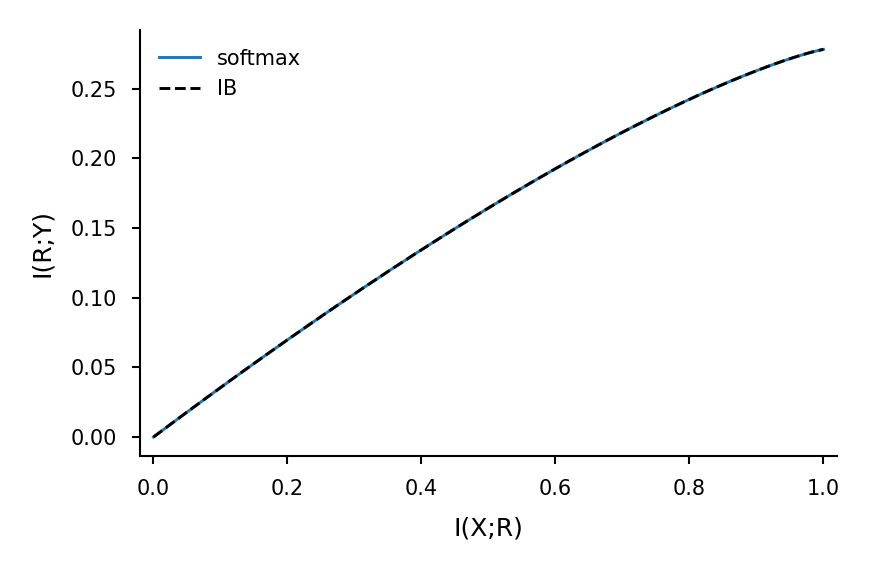

In [10]:
fig, axs = IB_bound_comparison_plot(softmax_curve, IB_bound_softmaxinit)
savefig(fig, 'FigureB15/beads_heuristic_IB-bound_comparison')

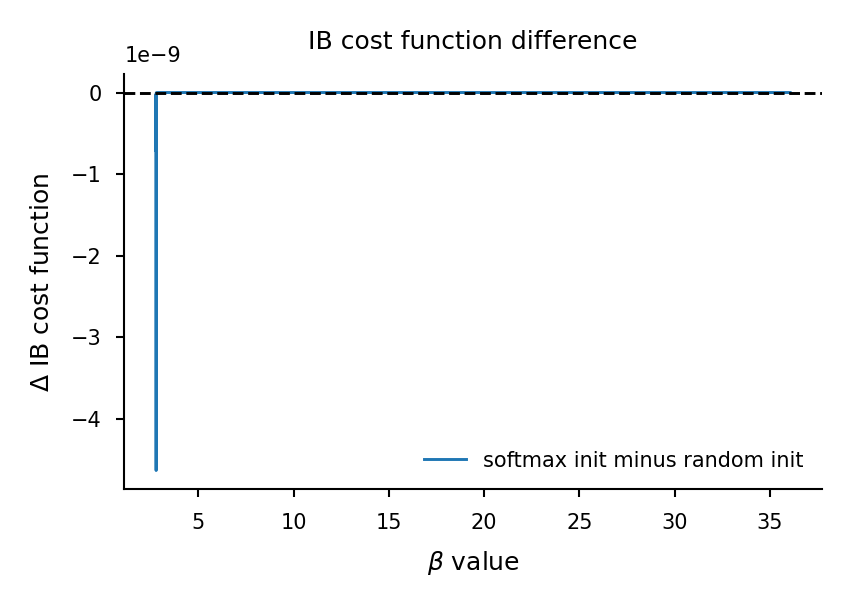

In [11]:
fig, axs = init_comparison_plot(IB_bound_softmaxinit,IB_bound_randinit)
savefig(fig, 'FigureB15/beads_heuristic_IB-init_comparison')

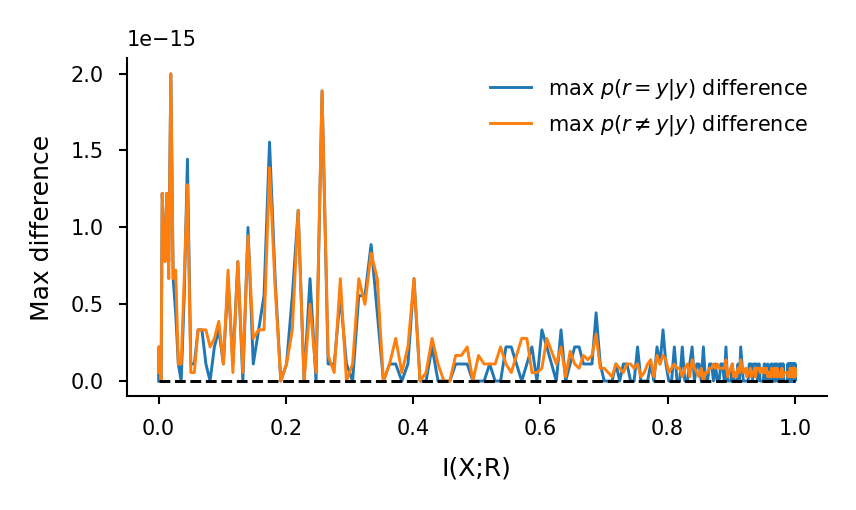

In [12]:
fig, axs = softmax_soln_condition_check(IB_bound_softmaxinit)
savefig(fig, 'FigureB15/beads_heuristic_softmax_soln_condition_check')

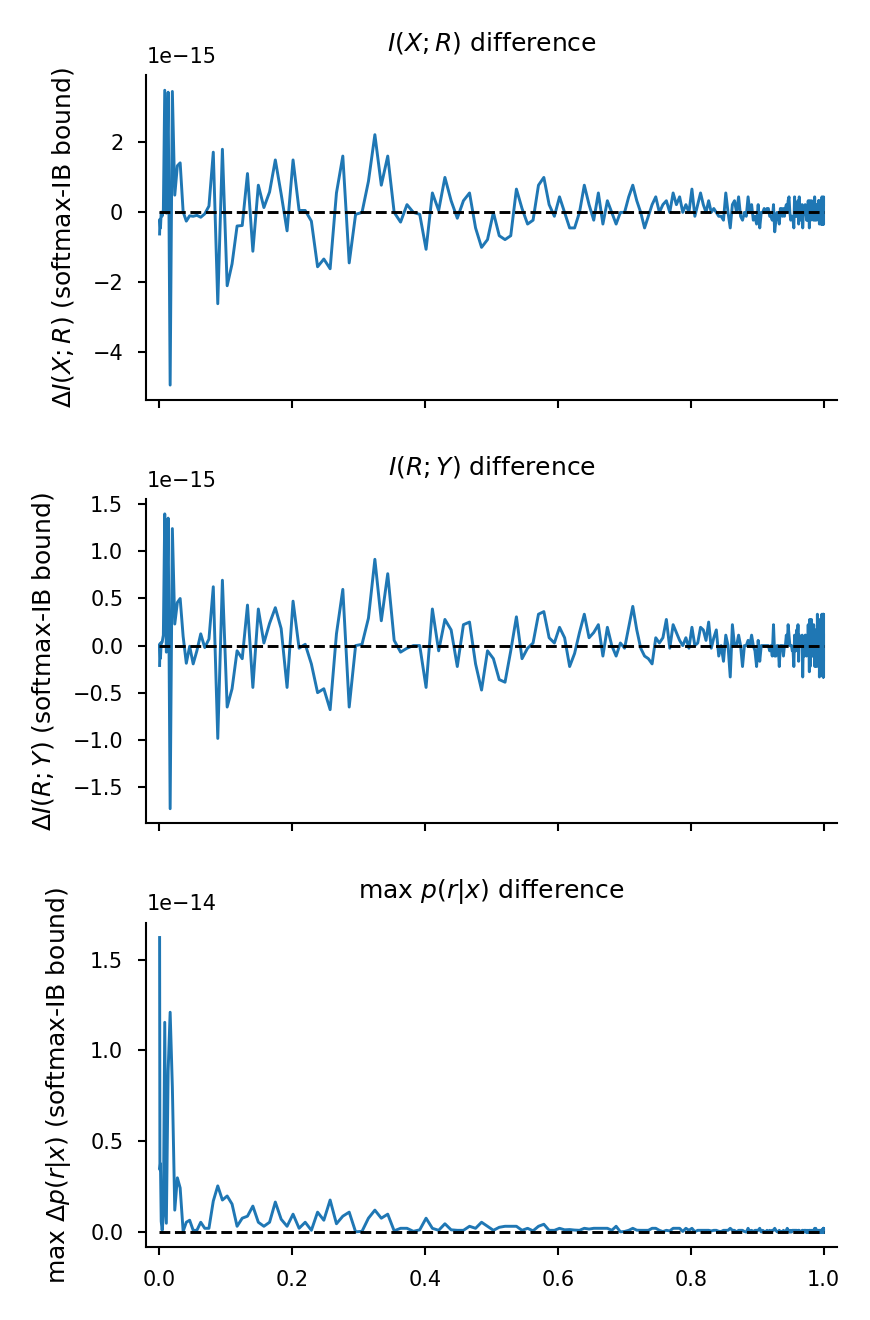

In [13]:
fig, axs = compare_softmax_to_IB(softmax_curve,IB_bound_softmaxinit)
savefig(fig, 'FigureB15/beads_heuristic_compare_softmax_soln_to_IB')

## Figure B16
Softmax solution compared to IB bound for fully-optimal strategy, horse-prediction task (intermediate W-S ratio)

In [4]:
X = utils.get_shapes_Xset()
p_XgY = utils.P_shapecomb_g_horse(X,paramdict['midWS']['weakLLR'],paramdict['midWS']['WSratio'],paramdict['midWS']['p1'])
softmax_curve, IB_bound_randinit, IB_bound_softmaxinit = get_beta_matched_bounds(p_XgY,p_Y,N_b=N_b_ib,max_b=max_b_ib,iterlimit=IB_iterlimit,N_threads=N_threads,base_seed=209,enforce_monotonic=False)

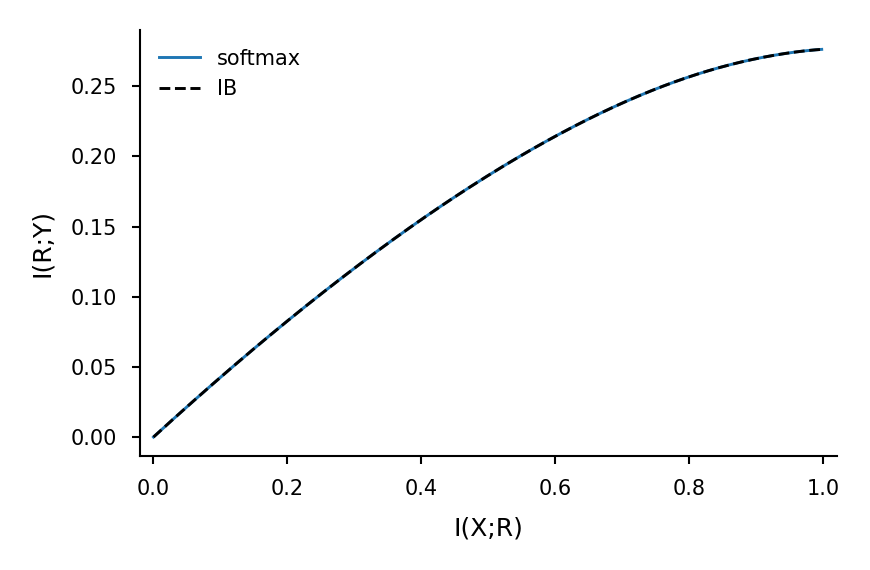

In [5]:
fig, axs = IB_bound_comparison_plot(softmax_curve, IB_bound_softmaxinit)
savefig(fig, 'FigureB16/horses_fully-opt_IB-bound_comparison')

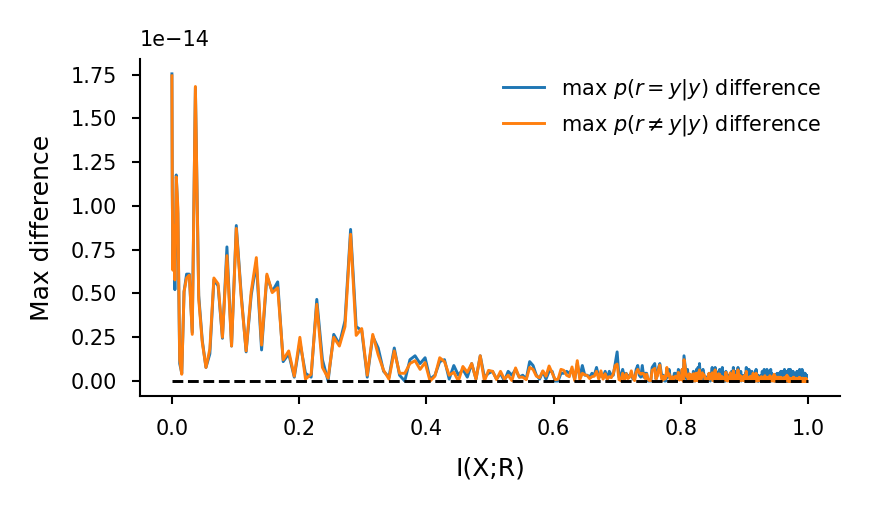

In [6]:
fig, axs = softmax_soln_condition_check(IB_bound_softmaxinit)
savefig(fig, 'FigureB16/horses_fully-opt_softmax_soln_condition_check')

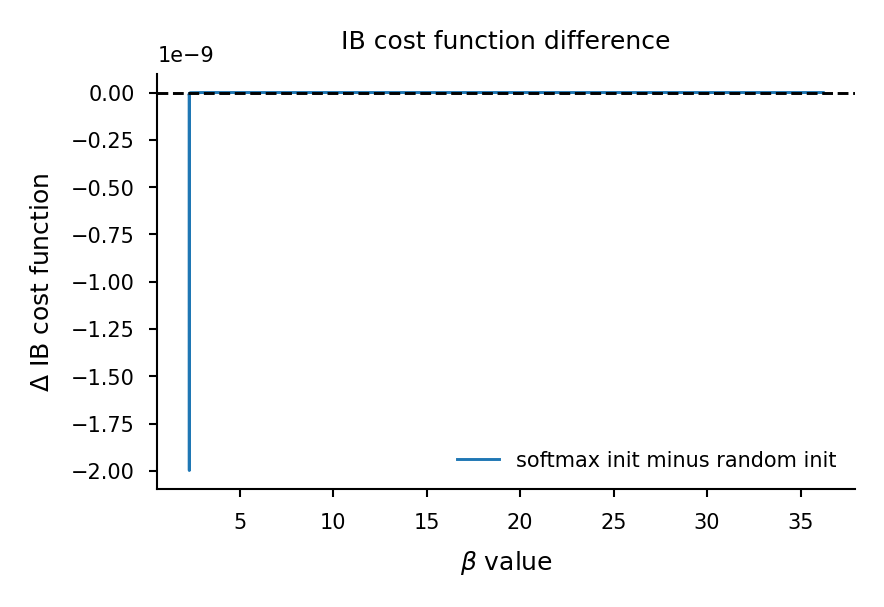

In [7]:
fig, axs = init_comparison_plot(IB_bound_softmaxinit,IB_bound_randinit)
savefig(fig, 'FigureB16/horses_fully-opt_IB-init_comparison')

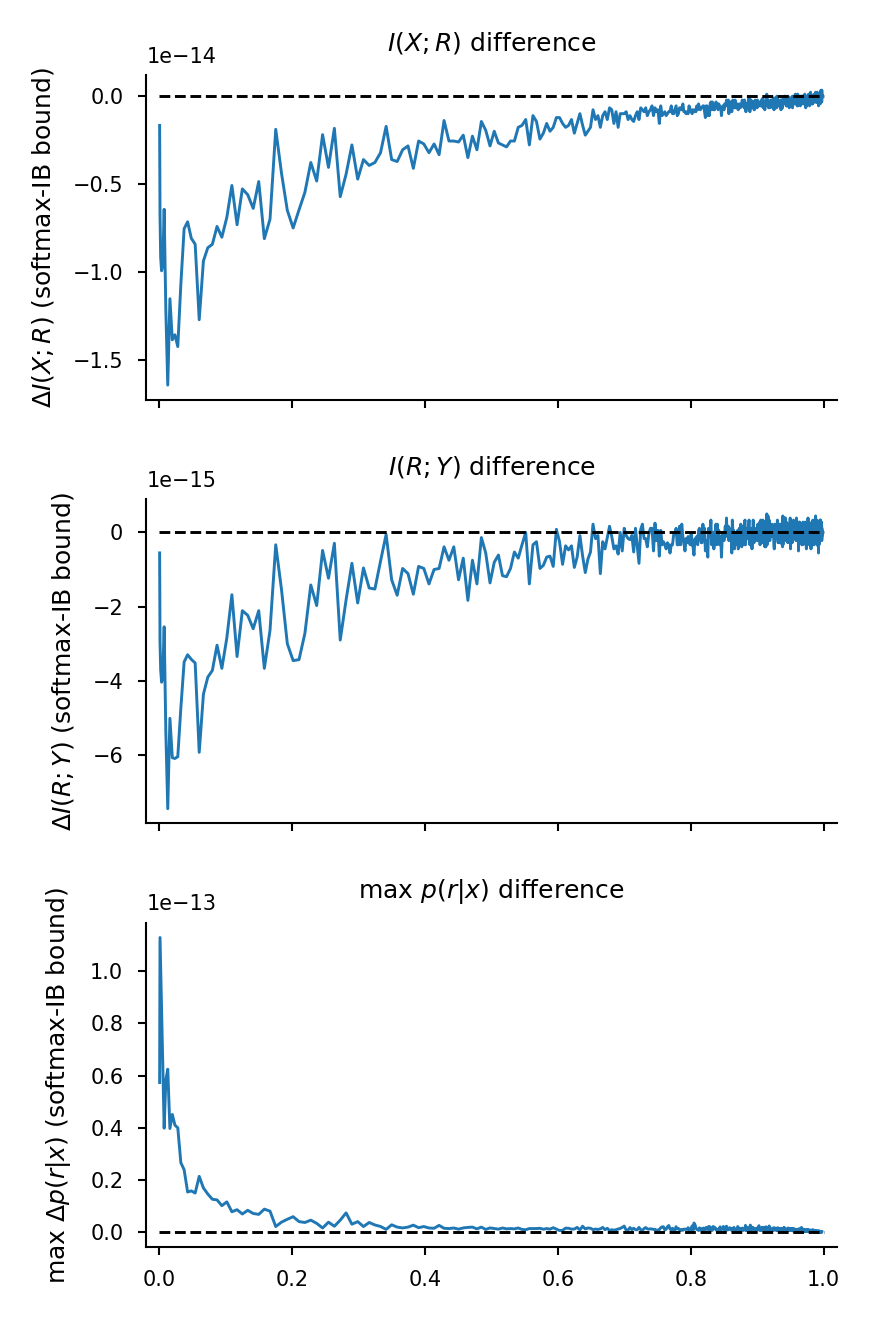

In [8]:
fig, axs = compare_softmax_to_IB(softmax_curve,IB_bound_softmaxinit)
savefig(fig, 'FigureB16/horses_fully-opt_compare_softmax_soln_to_IB')

## Figure B17
Softmax solution compared to IB bound for heuristic (equal-weights) strategy, horse-prediction task

In [24]:
X = utils.get_shapes_Xset(encoding='equal-weights')
p_XgY = utils.P_shapecomb_g_horse_ew(X,paramdict['midWS']['weakLLR'],paramdict['midWS']['WSratio'],paramdict['midWS']['p1'])
softmax_curve, IB_bound_randinit, IB_bound_softmaxinit = get_beta_matched_bounds(p_XgY,p_Y,N_b=N_b_ib,max_b=max_b_ib,iterlimit=IB_iterlimit,N_threads=N_threads,base_seed=209,enforce_monotonic=False)

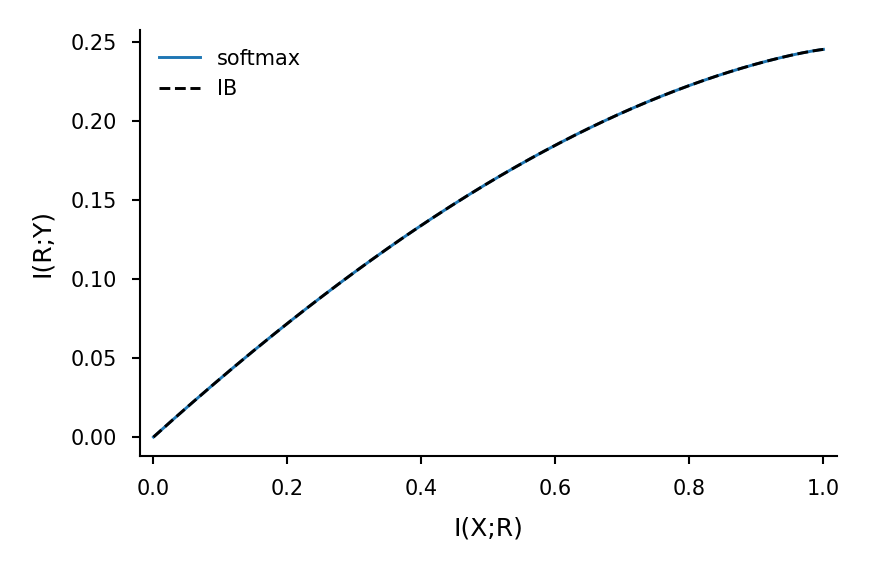

In [25]:
fig, axs = IB_bound_comparison_plot(softmax_curve, IB_bound_softmaxinit)
savefig(fig, 'FigureB17/horses_heuristic_IB-bound_comparison')

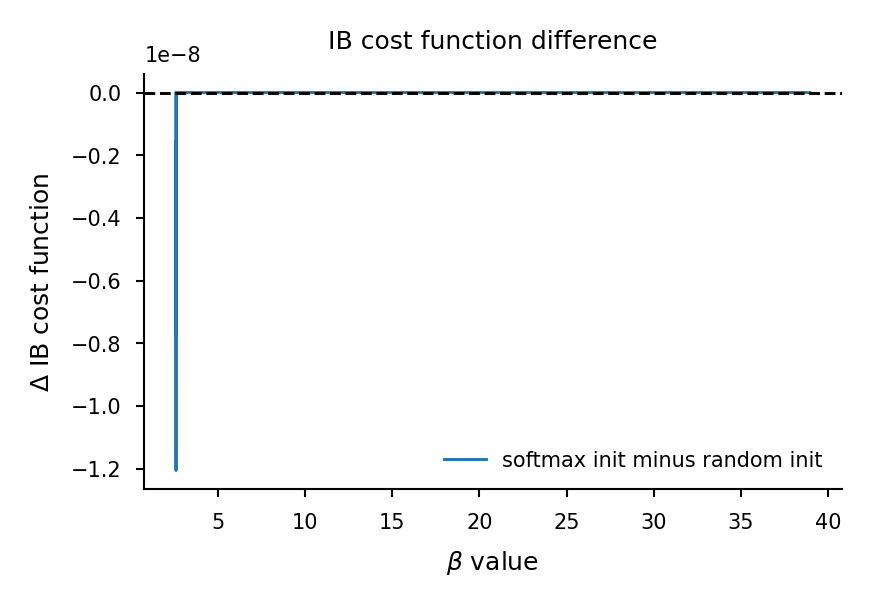

In [26]:
fig, axs = init_comparison_plot(IB_bound_softmaxinit,IB_bound_randinit)
savefig(fig, 'FigureB17/horses_heuristic_IB-init_comparison')

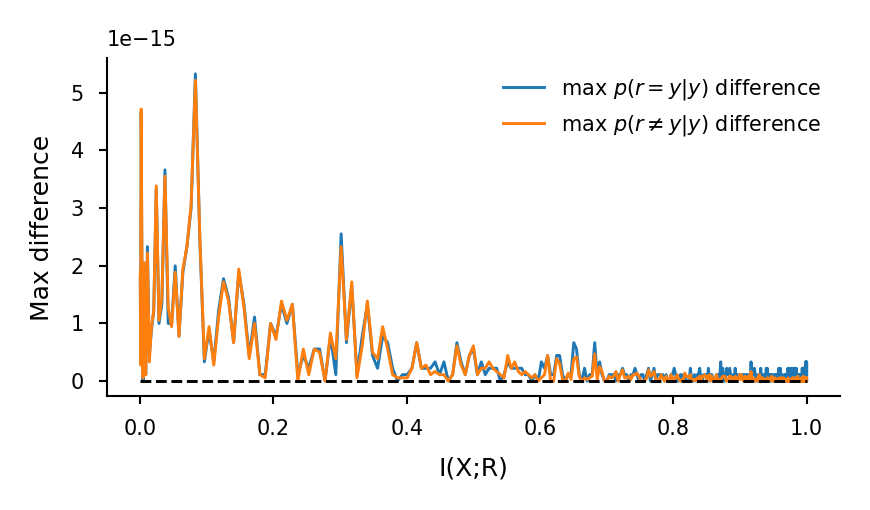

In [27]:
fig, axs = softmax_soln_condition_check(IB_bound_softmaxinit)
savefig(fig, 'FigureB17/horses_heuristic_softmax_soln_condition_check')

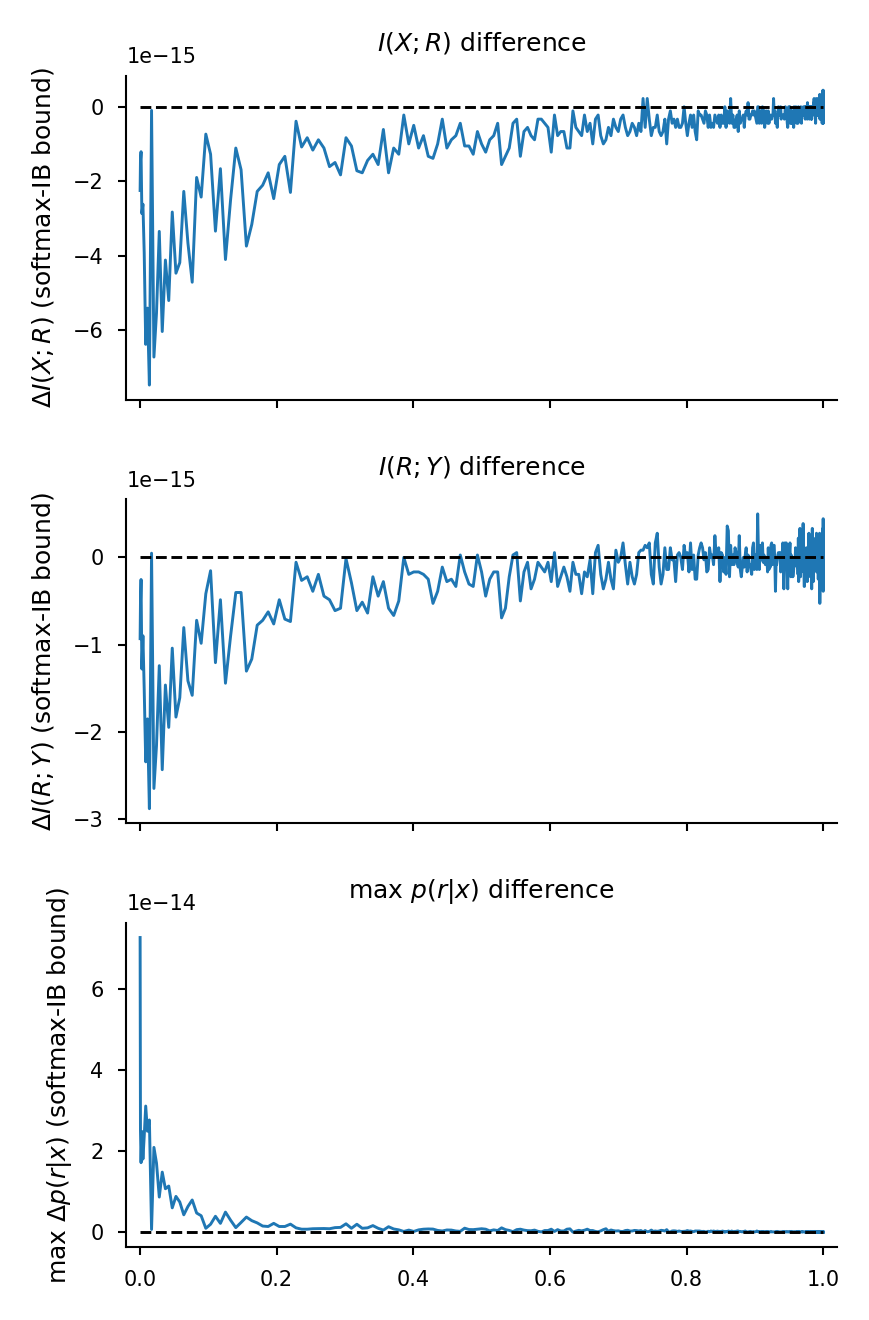

In [28]:
fig, axs = compare_softmax_to_IB(softmax_curve,IB_bound_softmaxinit)
savefig(fig, 'FigureB17/horses_heuristic_compare_softmax_soln_to_IB')

## Figure B18
Softmax solution compared to IB bound for optimal (7-back) strategy, three jar (three latent state) version of the bead prediction task

In [29]:
import itertools

h_=0.98
h1_=(1-h_)/2
p0_=0.7
p1_=(1-p0_)/2
P0=np.array([[1],[1],[1]])/3

p_Y_ = np.array([[1, 1, 1]]) / 3

H_ = np.array([
    [h_, h1_, h1_],
    [h1_, h_, h1_],
    [h1_, h1_, h_]])
E_ = np.array([
    [p0_, p1_, p1_],
    [p1_, p0_, p1_],
    [p1_, p1_, p0_]
])

X = np.array([seq for seq in itertools.product([0,1,2],repeat=7)])
p_XgY = utils.P_beads_g_jar(X,E_,H_)

softmax_curve, IB_bound_randinit, IB_bound_softmaxinit = get_beta_matched_bounds(p_XgY,p_Y_,N_b=N_b_ib,max_b=max_b_ib,iterlimit=IB_iterlimit,N_threads=N_threads,base_seed=209,enforce_monotonic=False,sort_by_beta=False)

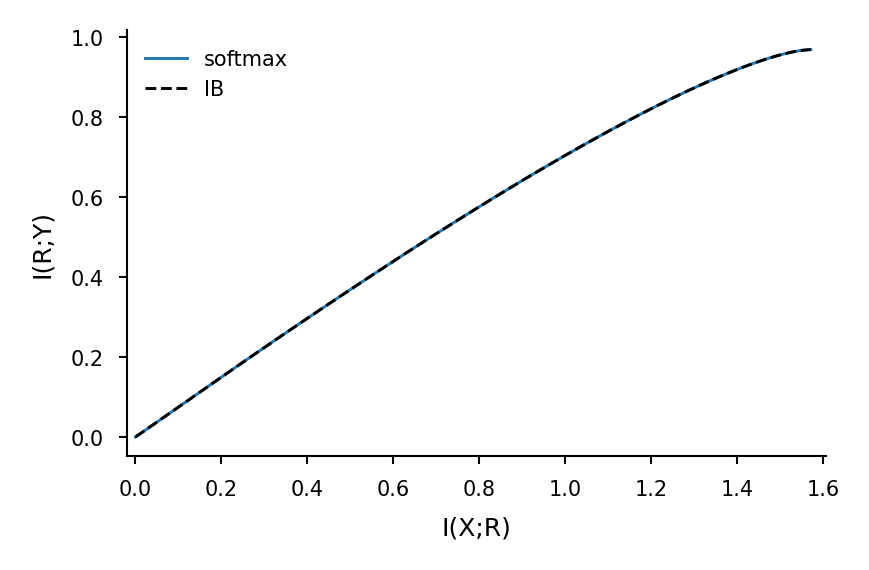

In [30]:
fig, axs = IB_bound_comparison_plot(softmax_curve, IB_bound_softmaxinit)
savefig(fig, 'FigureB18/three-jar-beads_fully-opt_IB-bound_comparison')

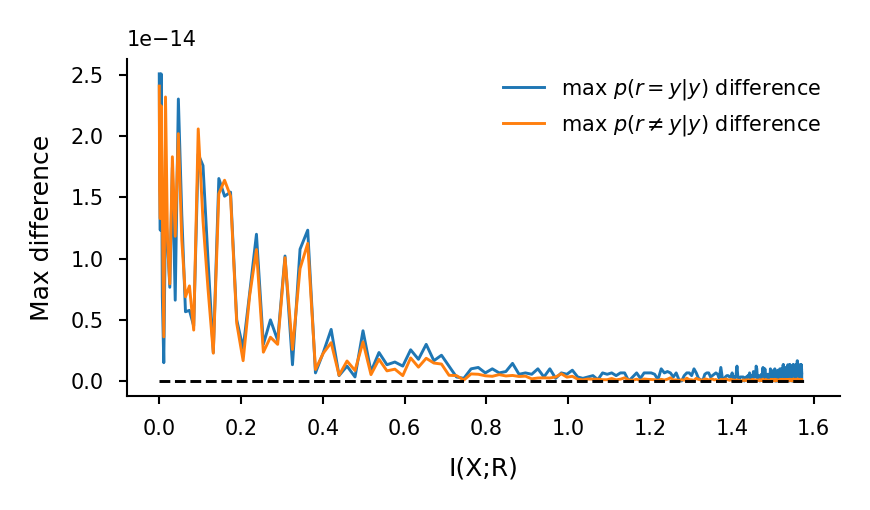

In [31]:
fig, axs = softmax_soln_condition_check(IB_bound_softmaxinit)
savefig(fig, 'FigureB18/three-jar-beads_fully-opt_softmax_soln_condition_check')

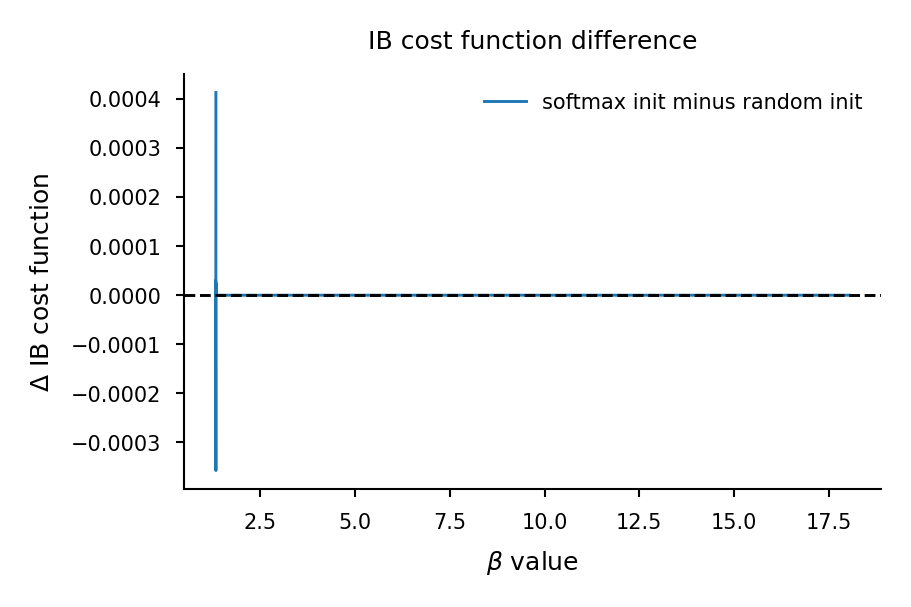

In [32]:
fig, axs = init_comparison_plot(IB_bound_softmaxinit,IB_bound_randinit)
savefig(fig, 'FigureB18/three-jar-beads_fully-opt_IB-init_comparison')

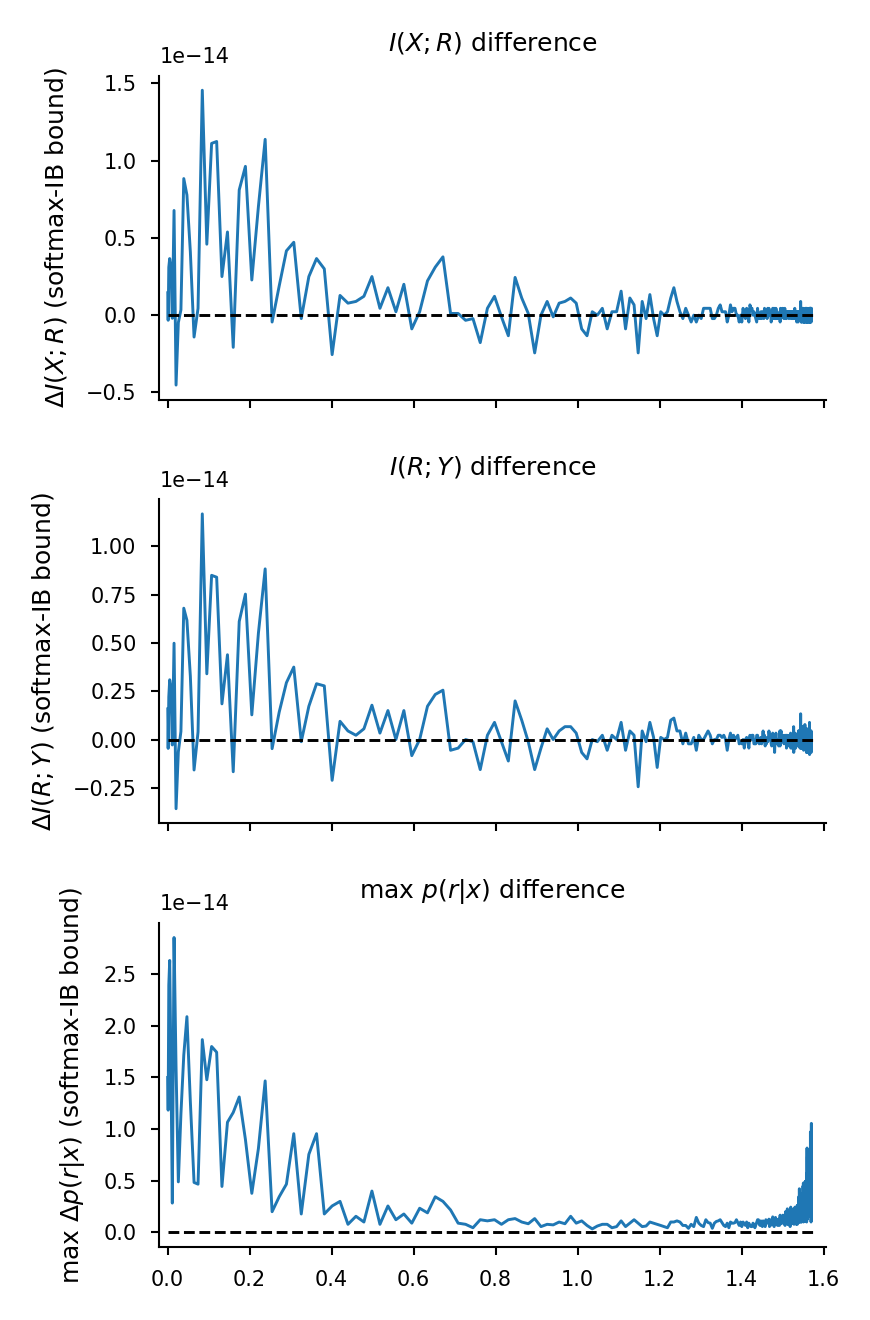

In [33]:
fig, axs = compare_softmax_to_IB(softmax_curve,IB_bound_softmaxinit)
savefig(fig, 'FigureB18/three-jar-beads_fully-opt_compare_softmax_soln_to_IB')

## Additional figures
IB bounds for the low and high ratio W-S ratio experiments, and for the ignore-weak heuristic

In [34]:
X = utils.get_shapes_Xset(encoding='ignore-weak')
p_XgY = utils.P_shapecomb_g_horse_iw(X,paramdict['midWS']['weakLLR'],paramdict['midWS']['WSratio'],paramdict['midWS']['p1'])
softmax_curve, IB_bound_randinit, IB_bound_softmaxinit = get_beta_matched_bounds(p_XgY,p_Y,N_b=N_b_ib,max_b=max_b_ib,iterlimit=IB_iterlimit,N_threads=N_threads,base_seed=209,enforce_monotonic=False)

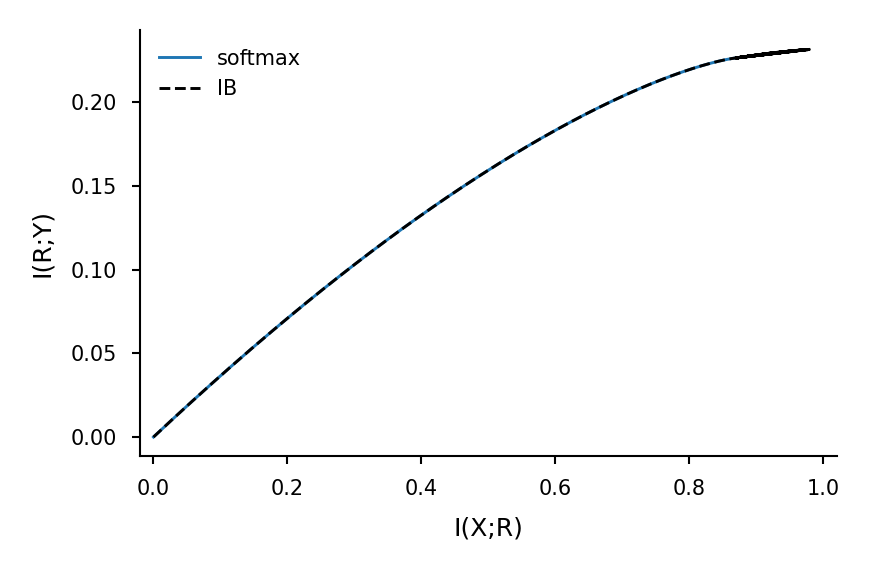

In [35]:
fig, axs = IB_bound_comparison_plot(softmax_curve, IB_bound_softmaxinit)

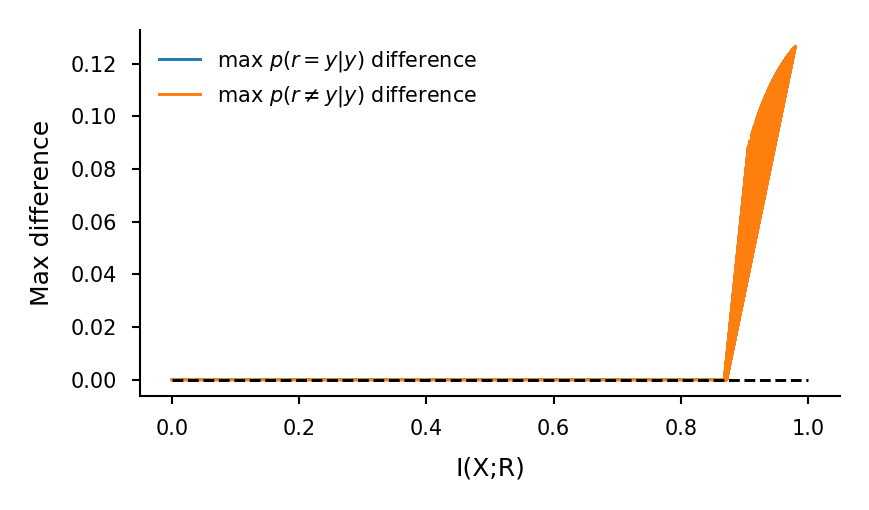

In [36]:
fig, axs = softmax_soln_condition_check(IB_bound_softmaxinit)

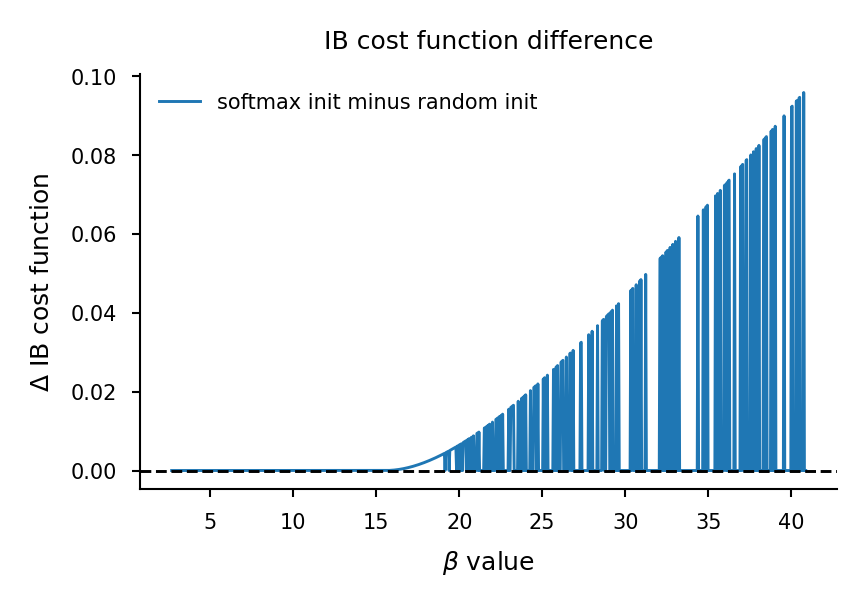

In [37]:
fig, axs = init_comparison_plot(IB_bound_softmaxinit,IB_bound_randinit)

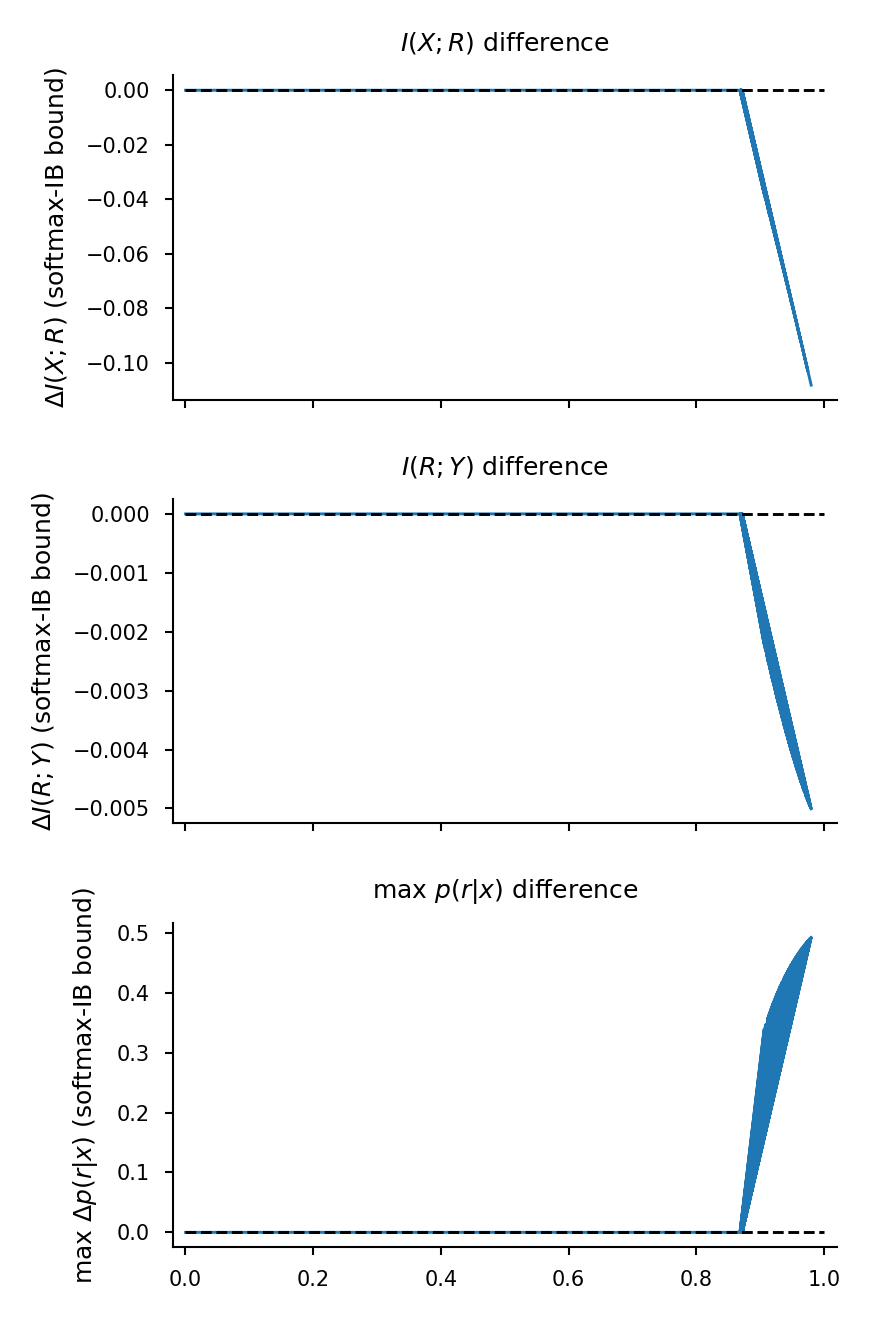

In [38]:
fig, axs = compare_softmax_to_IB(softmax_curve,IB_bound_softmaxinit)

In [9]:
X = utils.get_shapes_Xset()
p_XgY = utils.P_shapecomb_g_horse(X,paramdict['lowWS']['weakLLR'],paramdict['lowWS']['WSratio'],paramdict['lowWS']['p1'])
softmax_curve, IB_bound_randinit, IB_bound_softmaxinit = get_beta_matched_bounds(p_XgY,p_Y,N_b=N_b_ib,max_b=max_b_ib,iterlimit=IB_iterlimit,N_threads=N_threads,base_seed=209,enforce_monotonic=False)

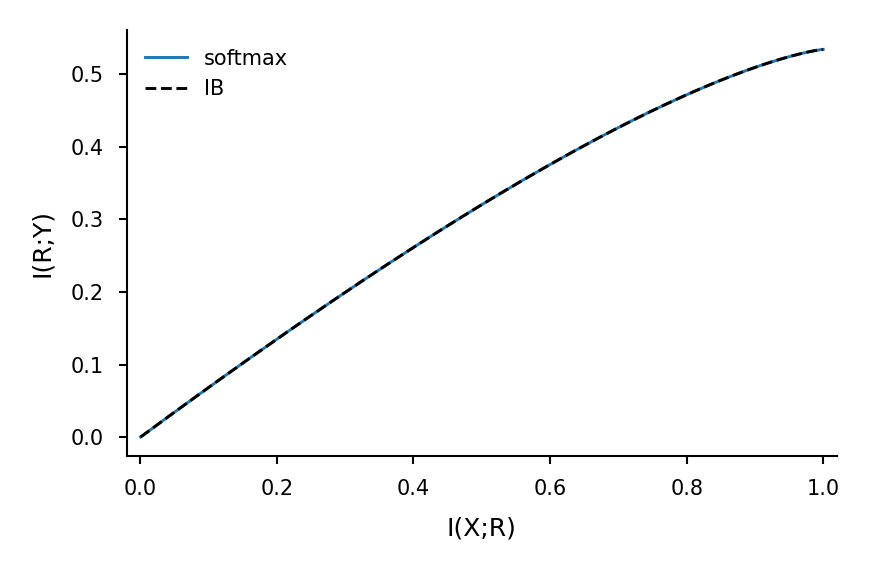

In [5]:
fig, axs = IB_bound_comparison_plot(softmax_curve, IB_bound_softmaxinit)

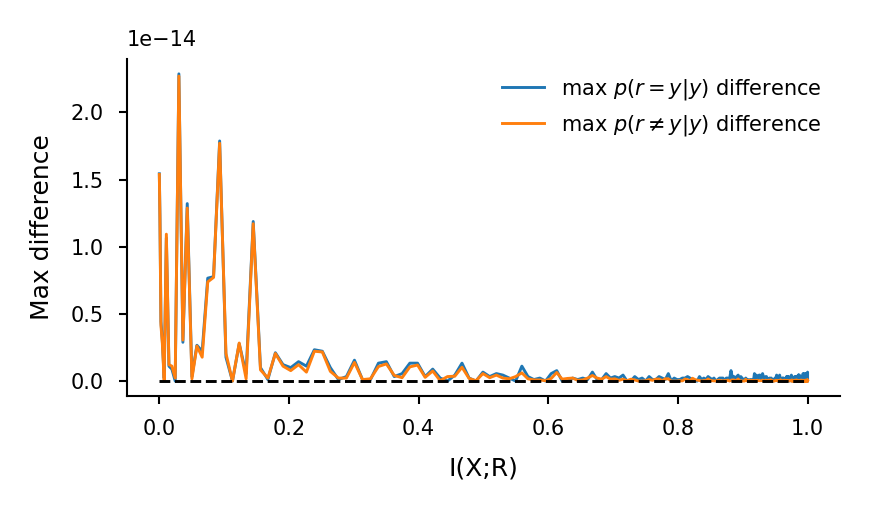

In [6]:
fig, axs = softmax_soln_condition_check(IB_bound_softmaxinit)

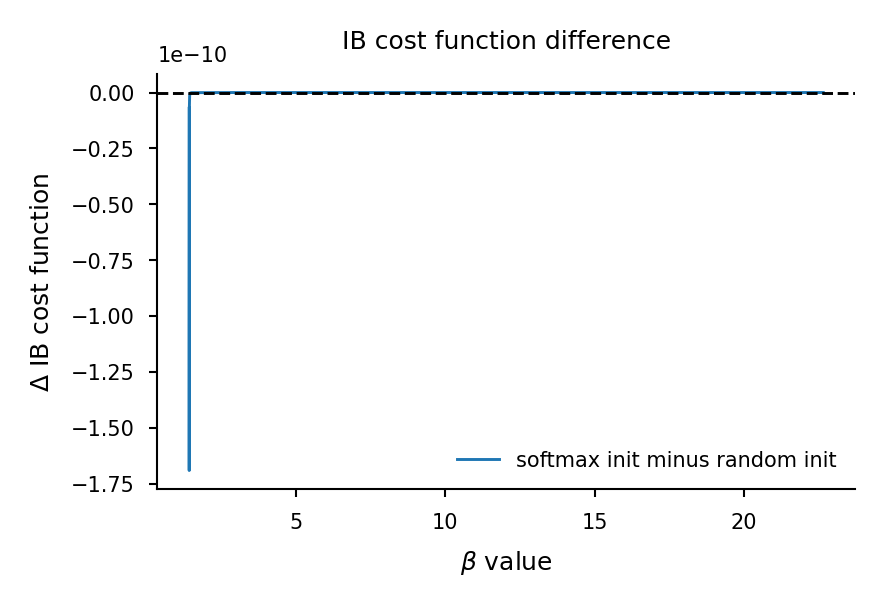

In [7]:
fig, axs = init_comparison_plot(IB_bound_softmaxinit,IB_bound_randinit)

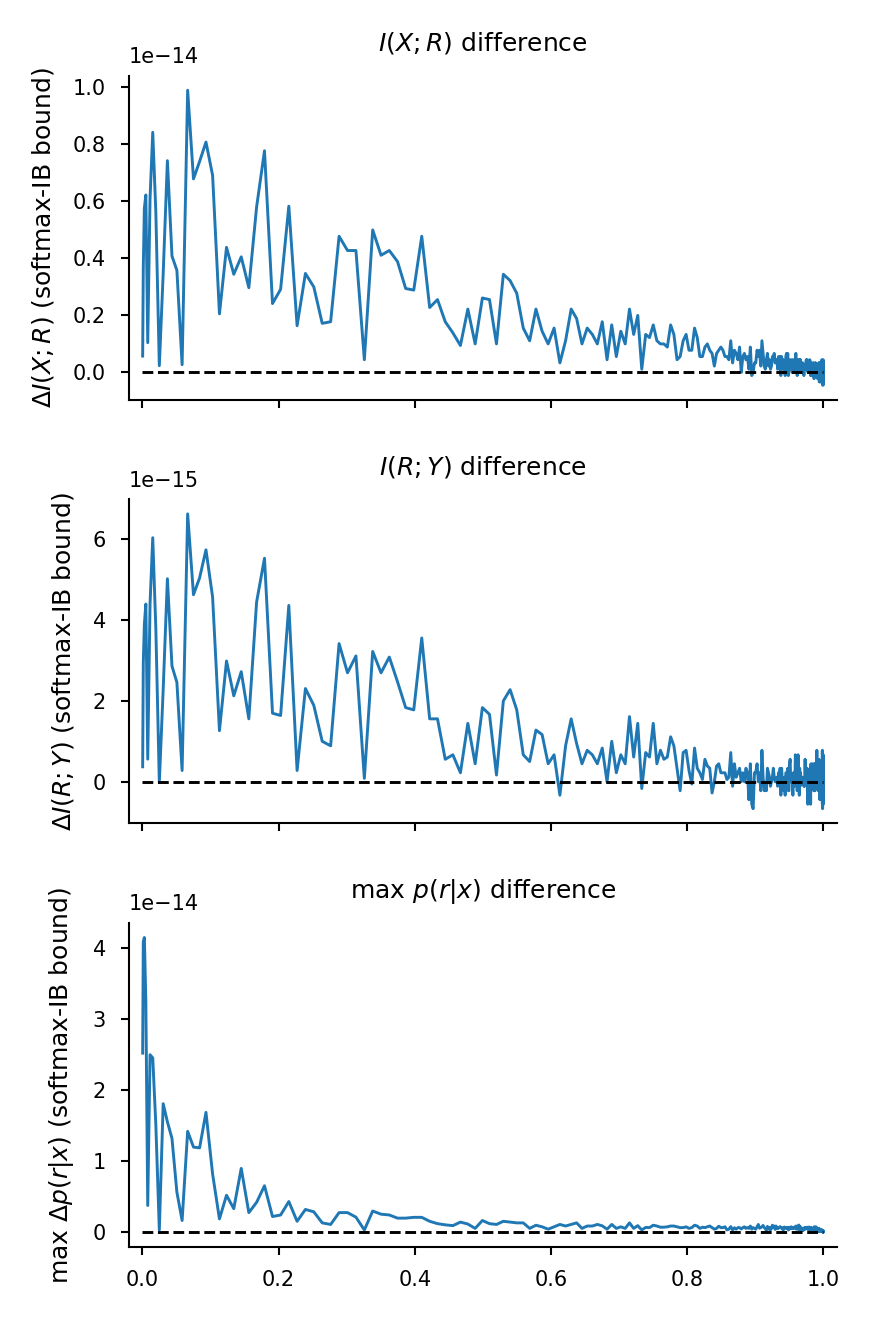

In [8]:
fig, axs = compare_softmax_to_IB(softmax_curve,IB_bound_softmaxinit)

In [10]:
X = utils.get_shapes_Xset(encoding='equal-weights')
p_XgY = utils.P_shapecomb_g_horse_ew(X,paramdict['lowWS']['weakLLR'],paramdict['lowWS']['WSratio'],paramdict['lowWS']['p1'])
softmax_curve, IB_bound_randinit, IB_bound_softmaxinit = get_beta_matched_bounds(p_XgY,p_Y,N_b=N_b_ib,max_b=max_b_ib,iterlimit=IB_iterlimit,N_threads=N_threads,base_seed=209,enforce_monotonic=False)

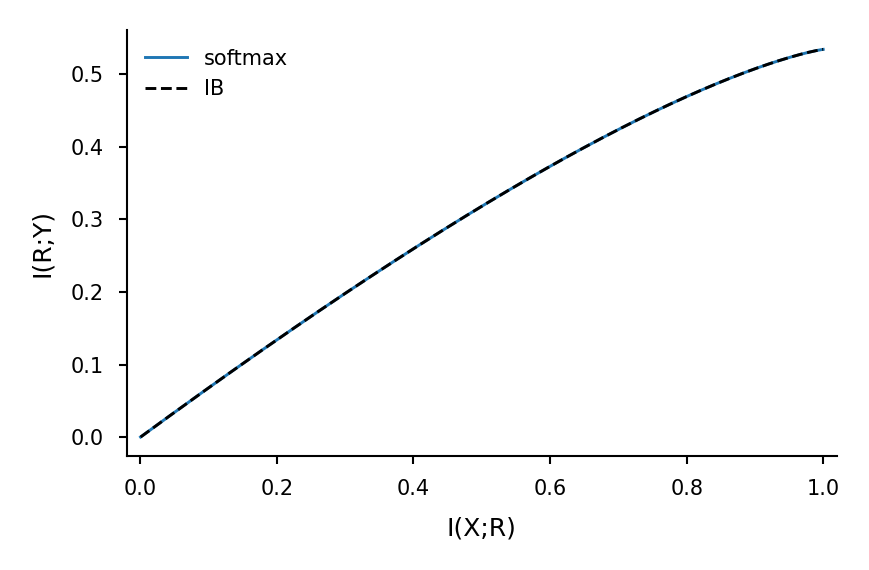

In [11]:
fig, axs = IB_bound_comparison_plot(softmax_curve, IB_bound_softmaxinit)

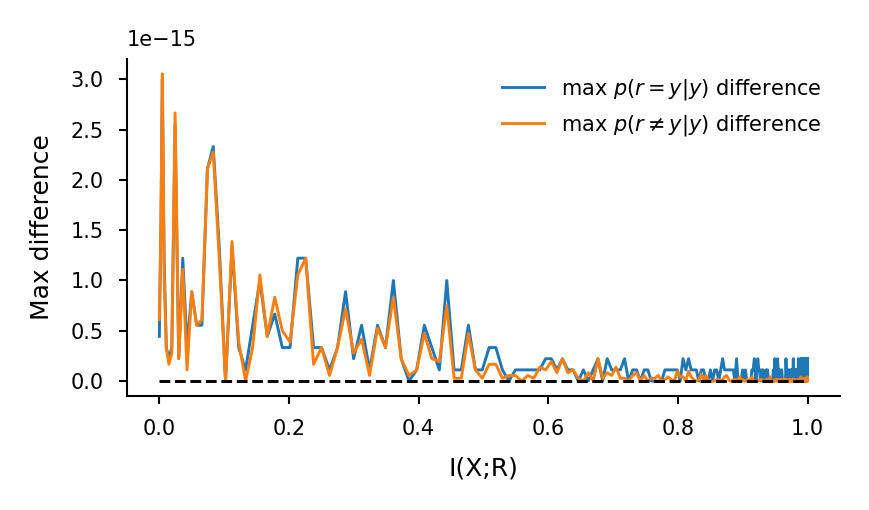

In [12]:
fig, axs = softmax_soln_condition_check(IB_bound_softmaxinit)

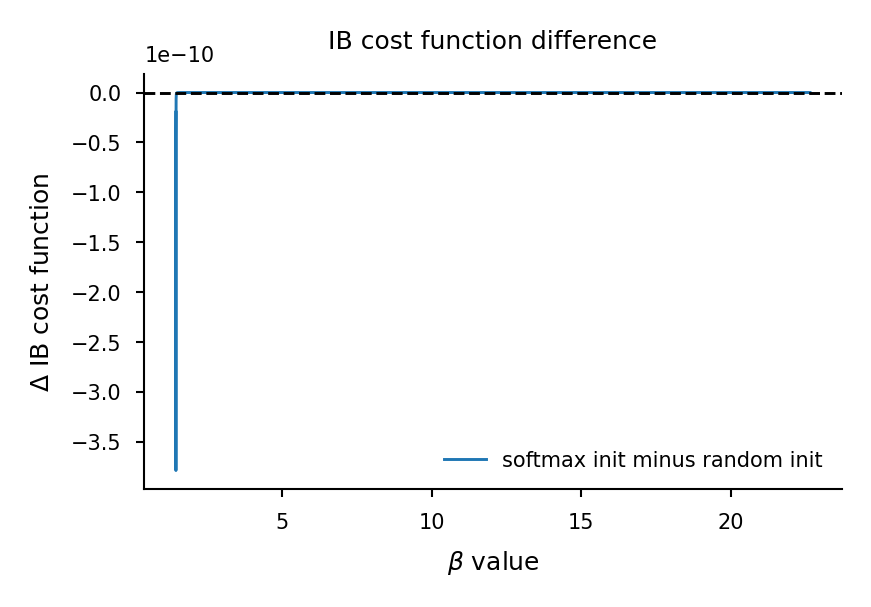

In [13]:
fig, axs = init_comparison_plot(IB_bound_softmaxinit,IB_bound_randinit)

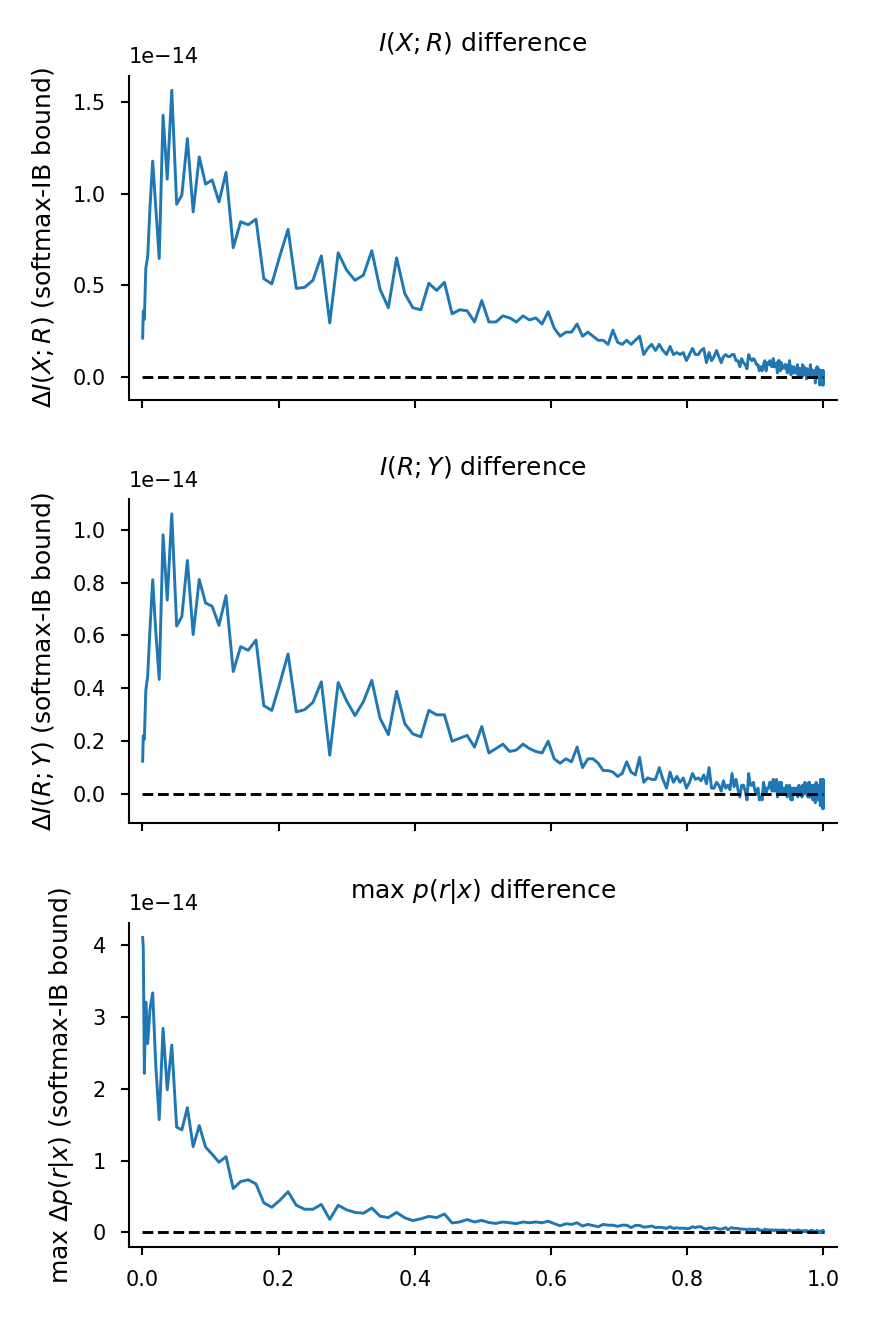

In [14]:
fig, axs = compare_softmax_to_IB(softmax_curve,IB_bound_softmaxinit)

In [10]:
X = utils.get_shapes_Xset(encoding='ignore-weak')
p_XgY = utils.P_shapecomb_g_horse_iw(X,paramdict['lowWS']['weakLLR'],paramdict['lowWS']['WSratio'],paramdict['lowWS']['p1'])
softmax_curve, IB_bound_randinit, IB_bound_softmaxinit = get_beta_matched_bounds(p_XgY,p_Y,N_b=N_b_ib,max_b=max_b_ib,iterlimit=IB_iterlimit,N_threads=N_threads,base_seed=209,enforce_monotonic=False)

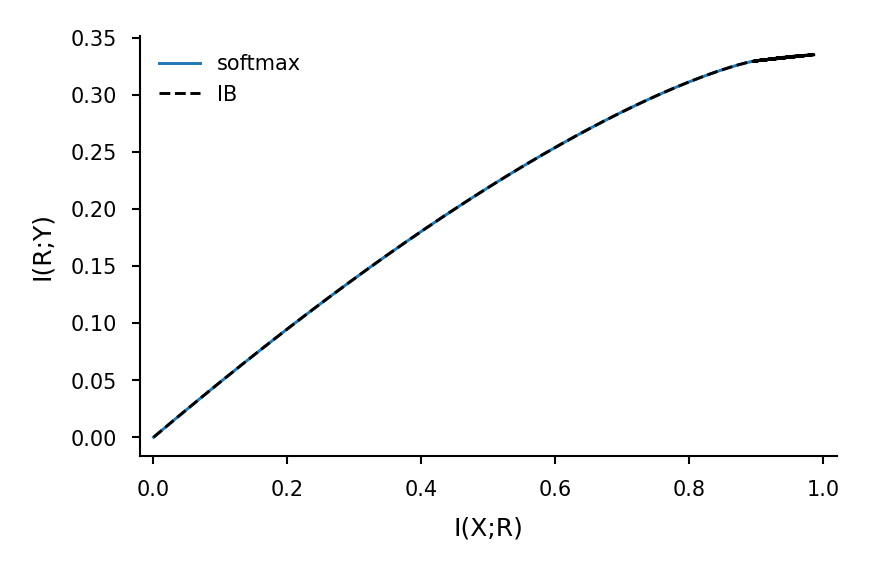

In [11]:
fig, axs = IB_bound_comparison_plot(softmax_curve, IB_bound_softmaxinit)

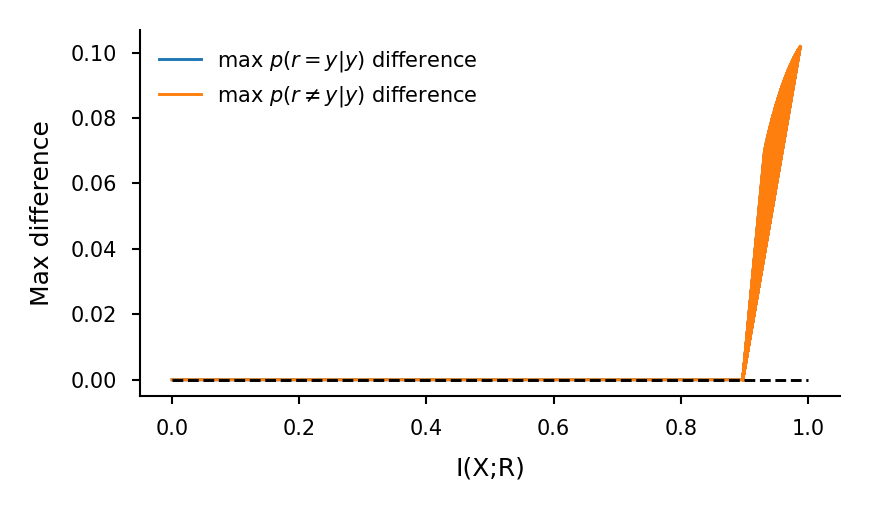

In [12]:
fig, axs = softmax_soln_condition_check(IB_bound_softmaxinit)

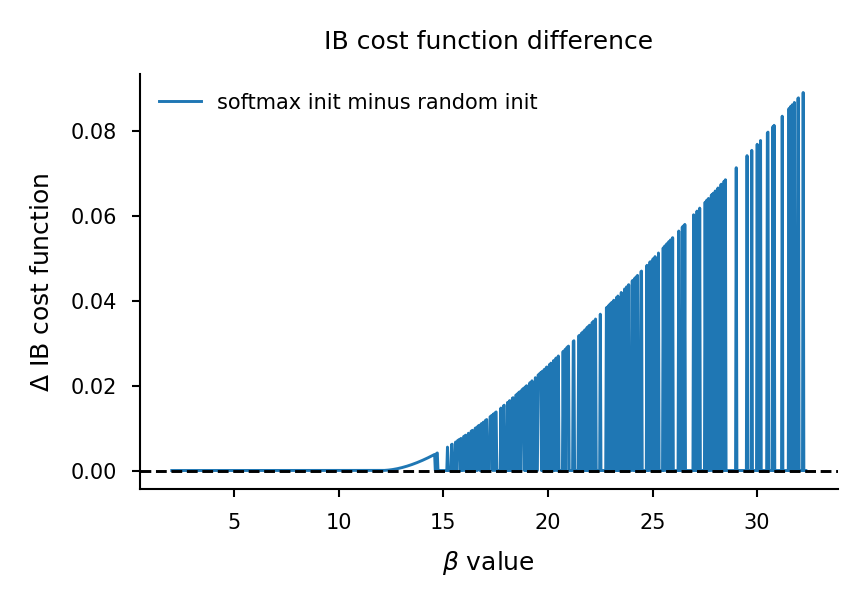

In [13]:
fig, axs = init_comparison_plot(IB_bound_softmaxinit,IB_bound_randinit)

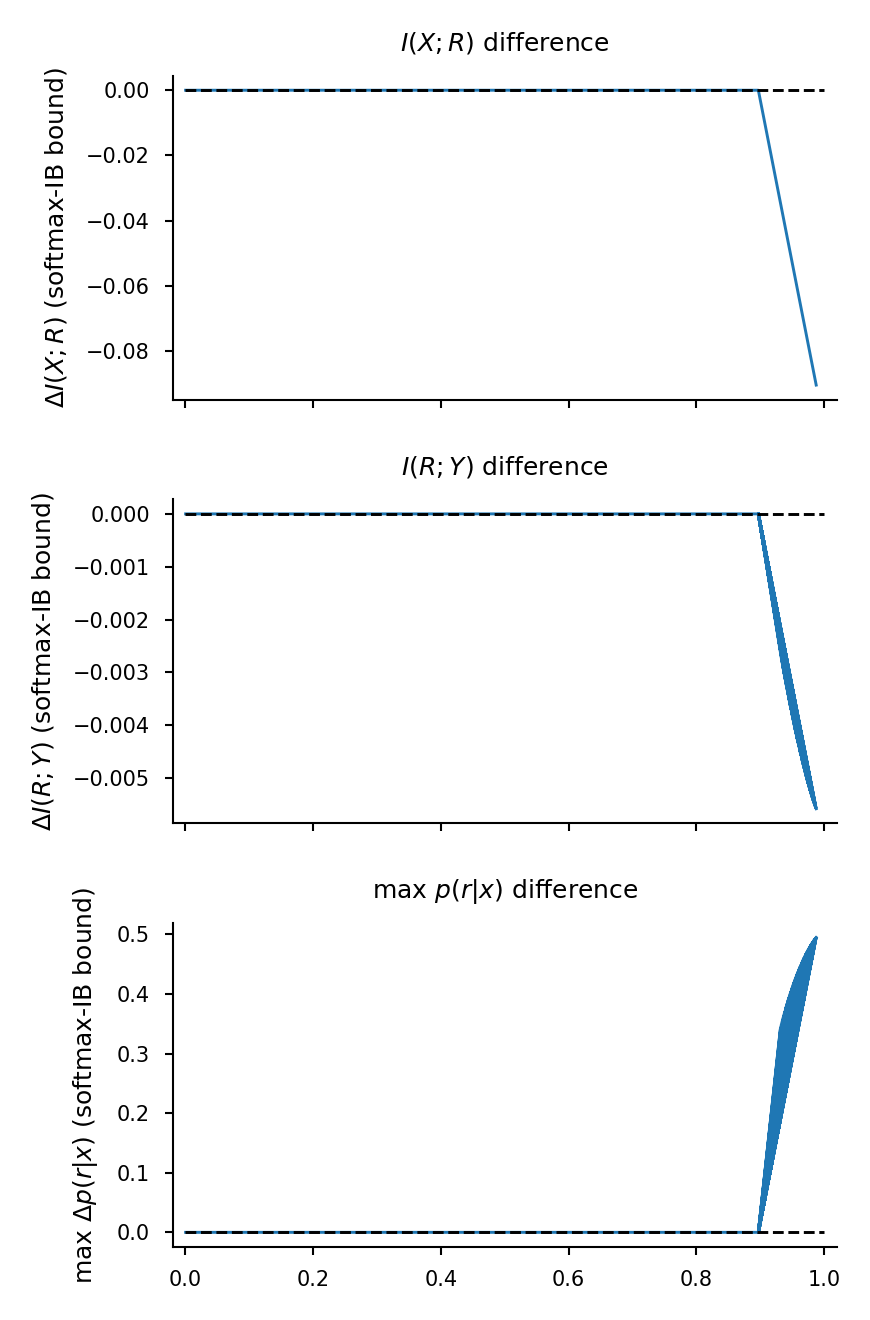

In [14]:
fig, axs = compare_softmax_to_IB(softmax_curve,IB_bound_softmaxinit)

In [15]:
X = utils.get_shapes_Xset()
p_XgY = utils.P_shapecomb_g_horse(X,paramdict['highWS']['weakLLR'],paramdict['highWS']['WSratio'],paramdict['highWS']['p1'])
softmax_curve, IB_bound_randinit, IB_bound_softmaxinit = get_beta_matched_bounds(p_XgY,p_Y,N_b=N_b_ib,max_b=max_b_ib,iterlimit=IB_iterlimit,N_threads=N_threads,base_seed=209,enforce_monotonic=False)

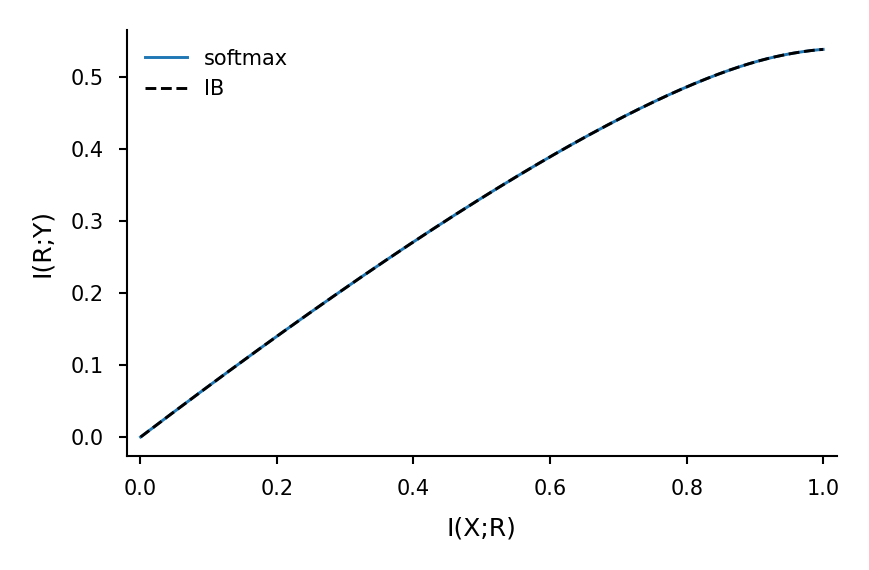

In [16]:
fig, axs = IB_bound_comparison_plot(softmax_curve, IB_bound_softmaxinit)

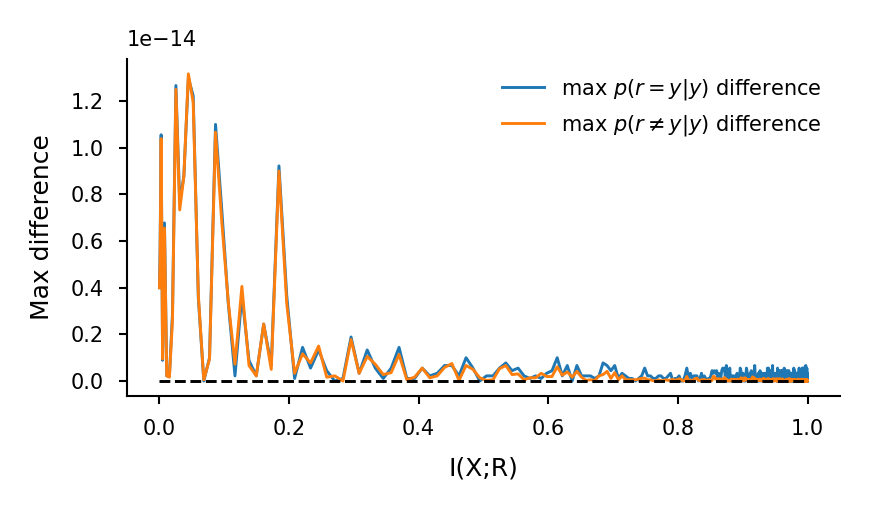

In [17]:
fig, axs = softmax_soln_condition_check(IB_bound_softmaxinit)

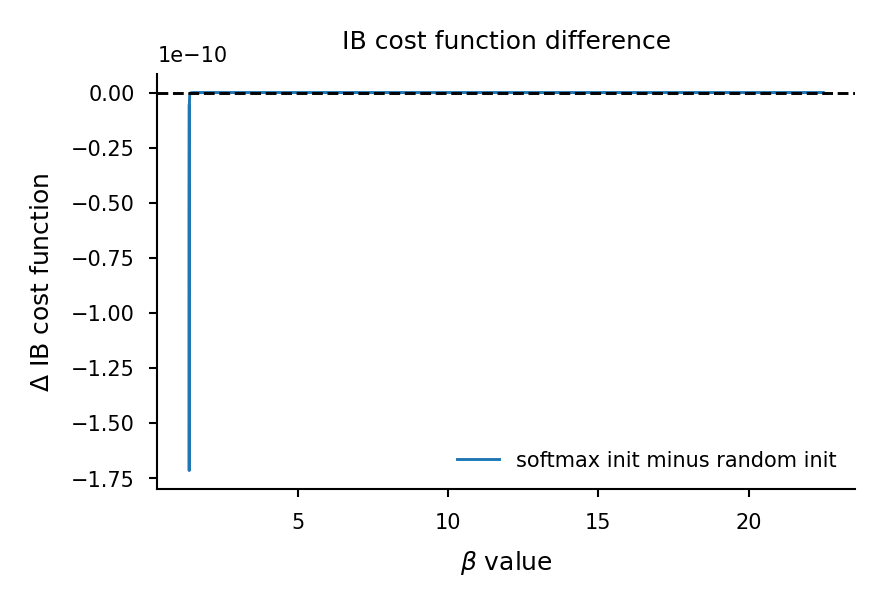

In [18]:
fig, axs = init_comparison_plot(IB_bound_softmaxinit,IB_bound_randinit)

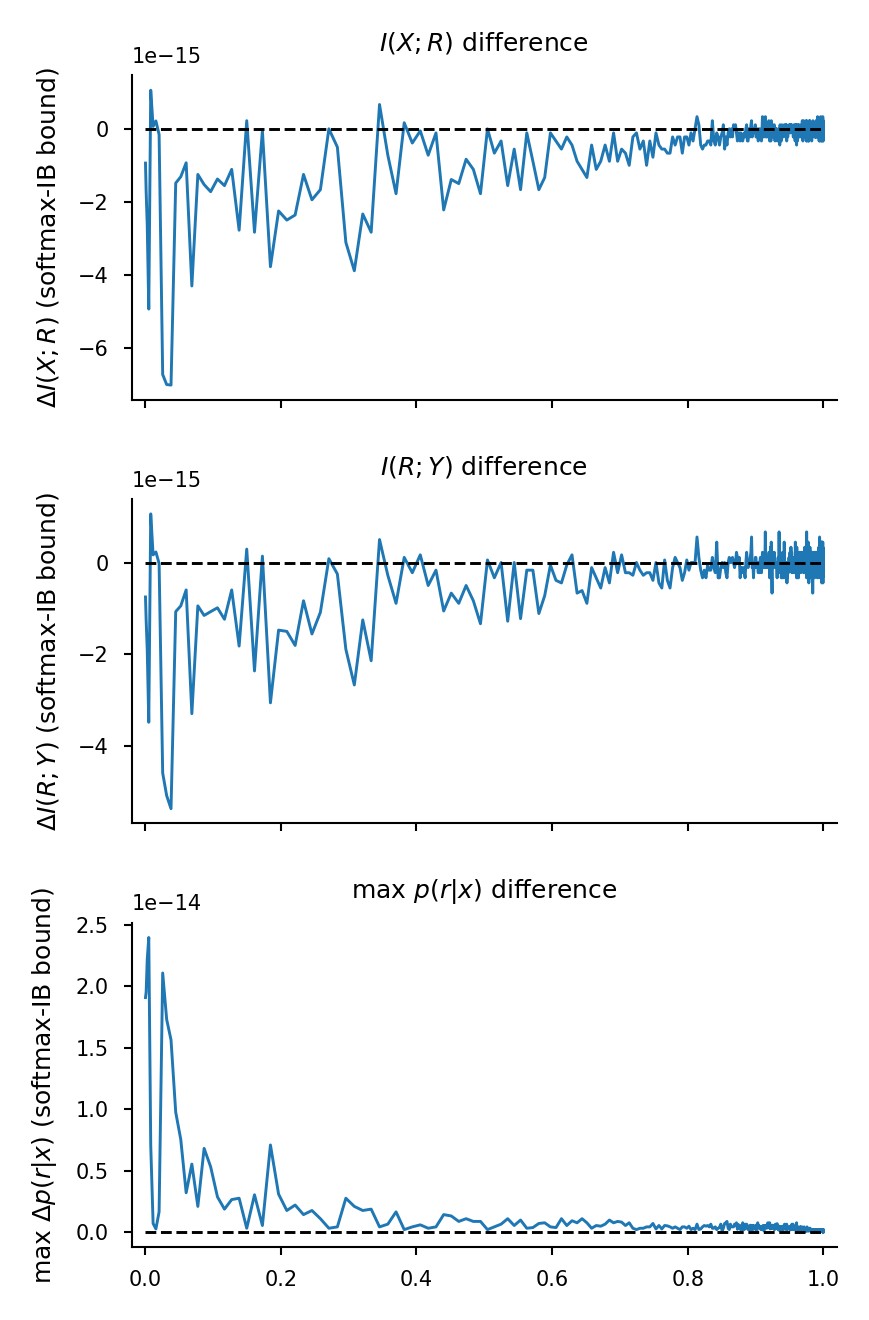

In [19]:
fig, axs = compare_softmax_to_IB(softmax_curve,IB_bound_softmaxinit)

In [20]:
X = utils.get_shapes_Xset(encoding='equal-weights')
p_XgY = utils.P_shapecomb_g_horse_ew(X,paramdict['highWS']['weakLLR'],paramdict['highWS']['WSratio'],paramdict['highWS']['p1'])
softmax_curve, IB_bound_randinit, IB_bound_softmaxinit = get_beta_matched_bounds(p_XgY,p_Y,N_b=N_b_ib,max_b=max_b_ib,iterlimit=IB_iterlimit,N_threads=N_threads,base_seed=209,enforce_monotonic=False)

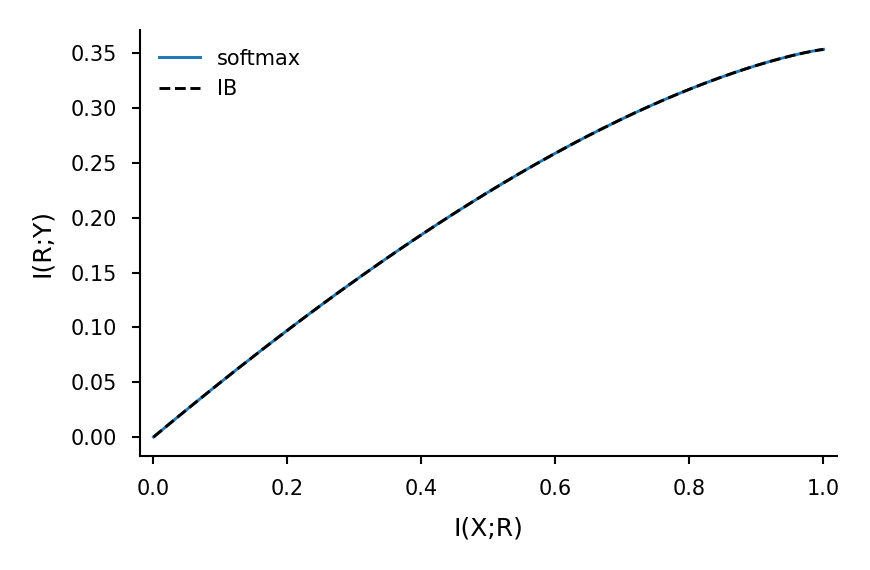

In [21]:
fig, axs = IB_bound_comparison_plot(softmax_curve, IB_bound_softmaxinit)

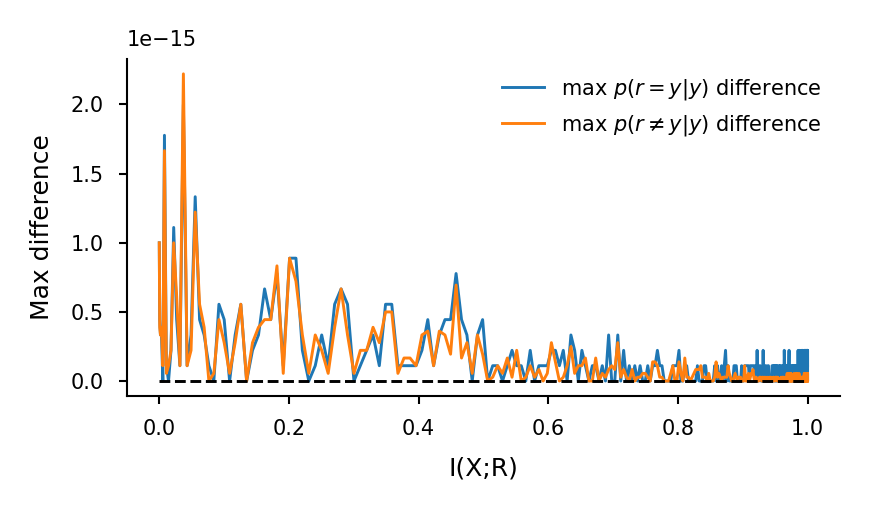

In [22]:
fig, axs = softmax_soln_condition_check(IB_bound_softmaxinit)

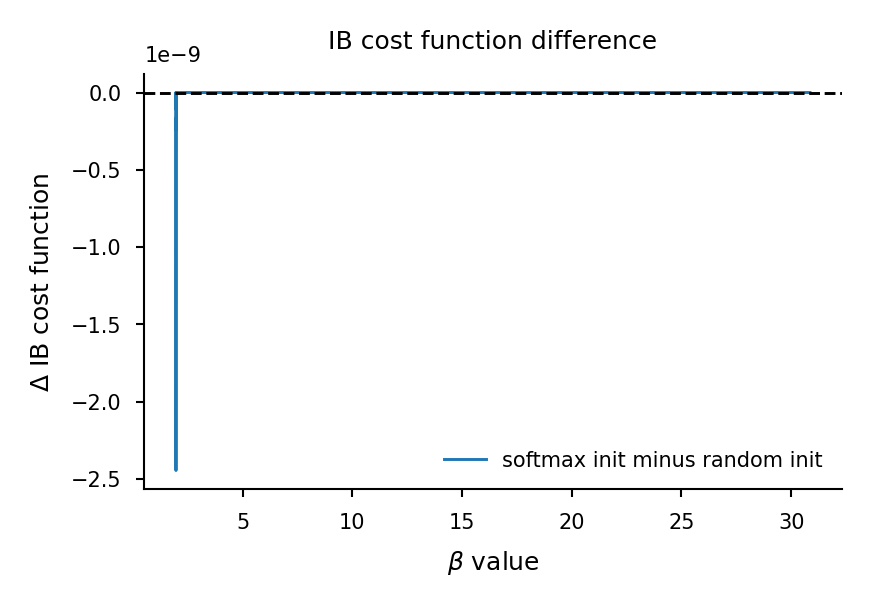

In [23]:
fig, axs = init_comparison_plot(IB_bound_softmaxinit,IB_bound_randinit)

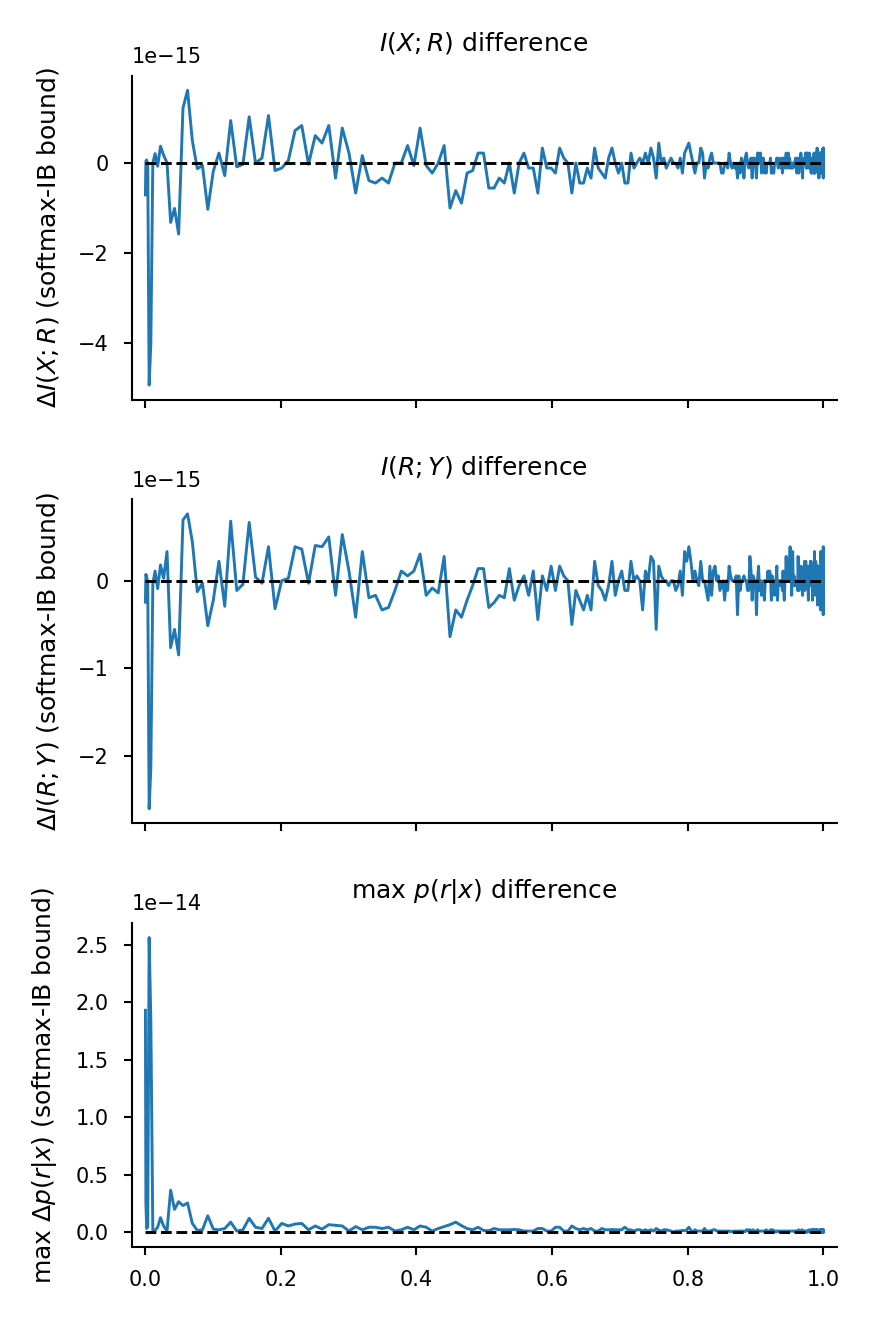

In [24]:
fig, axs = compare_softmax_to_IB(softmax_curve,IB_bound_softmaxinit)

In [16]:
X = utils.get_shapes_Xset(encoding='ignore-weak')
p_XgY = utils.P_shapecomb_g_horse_iw(X,paramdict['highWS']['weakLLR'],paramdict['highWS']['WSratio'],paramdict['highWS']['p1'])
softmax_curve, IB_bound_randinit, IB_bound_softmaxinit = get_beta_matched_bounds(p_XgY,p_Y,N_b=N_b_ib,max_b=max_b_ib,iterlimit=IB_iterlimit,N_threads=N_threads,base_seed=209,enforce_monotonic=False)

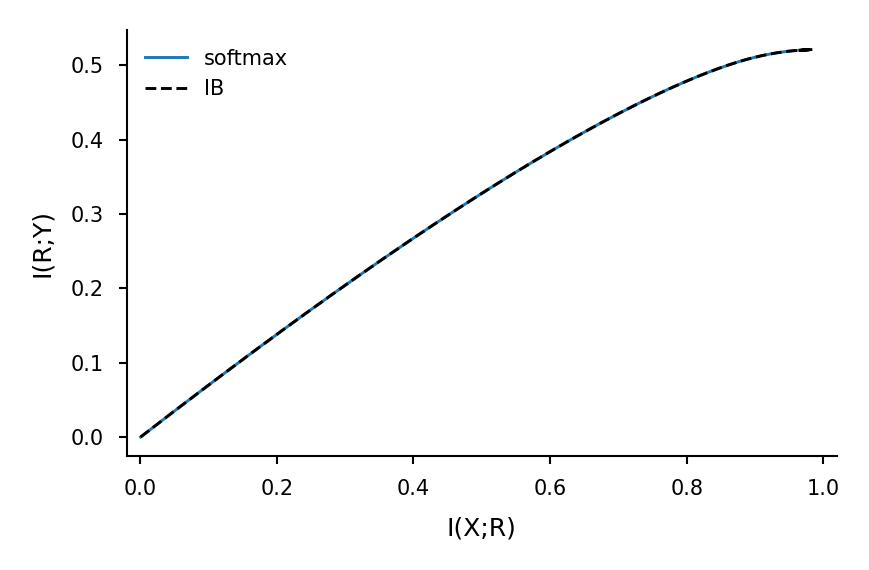

In [17]:
fig, axs = IB_bound_comparison_plot(softmax_curve, IB_bound_softmaxinit)

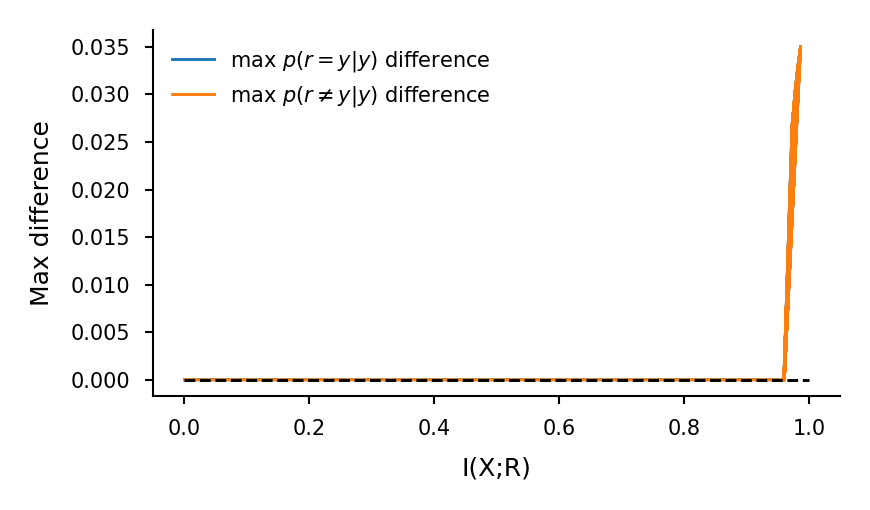

In [18]:
fig, axs = softmax_soln_condition_check(IB_bound_softmaxinit)

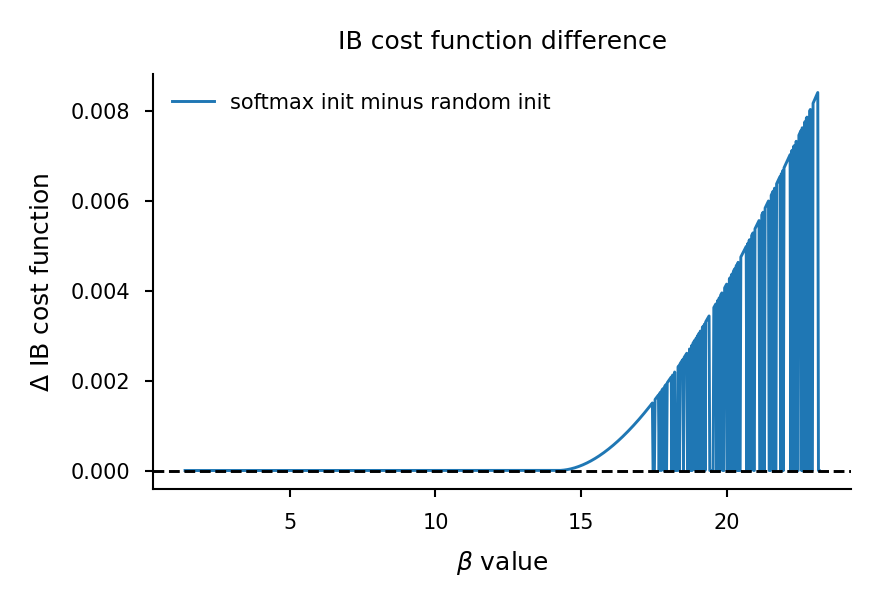

In [19]:
fig, axs = init_comparison_plot(IB_bound_softmaxinit,IB_bound_randinit)

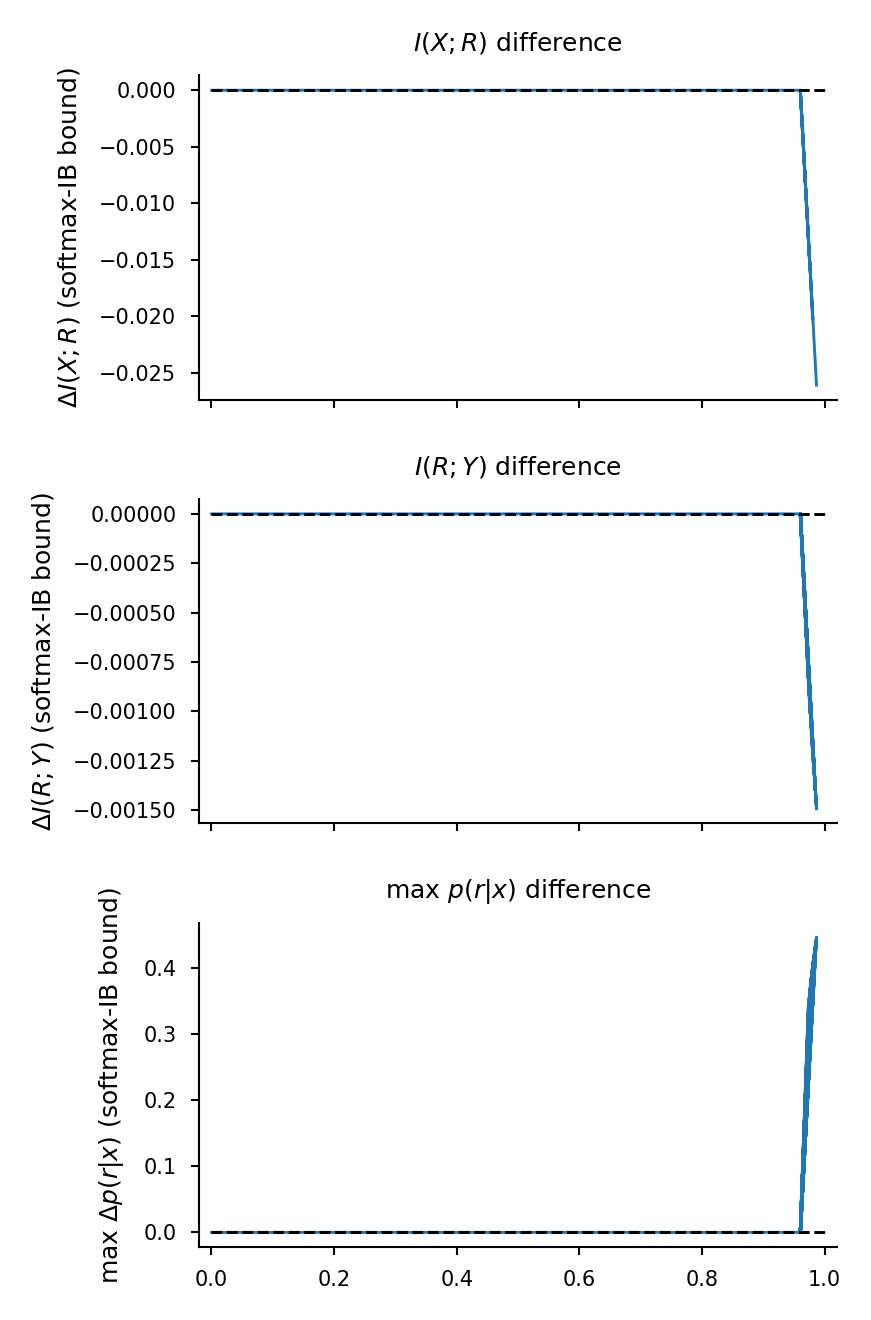

In [20]:
fig, axs = compare_softmax_to_IB(softmax_curve,IB_bound_softmaxinit)